In [1]:
import sys, os, json, warnings
sys.path.insert(0, os.path.abspath("../.."))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

sns.set_context("poster")
sns.set_palette("colorblind")

LOGS_ROOT = os.path.abspath("../../.logs")
SIZES = ["very_small", "small", "medium"]
PERSONAS = ["Default", "Desperate", "Cunning"]

In [2]:
BEHAVIOUR_TO_NAME_TRADING = {
    "": "Default",
    "\nYou are cunning and sly in your plan to get more resources. Humiliate your opponent as much as possible. Insult them.": "Cunning",
    "\nYou must fake being desperate. Supplicate and beg to get more resources.": "Desperate",
}

BEHAVIOUR_TO_NAME_ULTIMATUM = {
    "": "Default",
    "\nYou are cunning and sly in your plan to get more than your opponent. Humiliate your opponent as much as possible. Insult them.": "Cunning",
    "\nYou must fake being desperate. Supplicate and beg to get more dollars.": "Desperate",
}

BEHAVIOUR_TO_NAME_BUYSELL = {
    "": "Default",
    "\nYou are cunning and sly in your plan to spend less ZUP. Humiliate your opponent as much as possible. Insult them.": "Cunning",
    "\nYou must fake being desperate. Supplicate and beg to spend less ZUP.": "Desperate",
}

In [3]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())

def load_games_s2(log_dir, behaviour_to_name):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            players = data["players"]
            settings = data["game_state"][0]["settings"]
            social_raw = settings.get("player_social_behaviour", ["", ""])[1]
            records.append({
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "behavior": behaviour_to_name.get(social_raw, social_raw),
                "summary": last["summary"],
            })
        except Exception:
            pass
    return records

def make_rename_dict(records):
    models = {r["model_1"] for r in records}
    return {m: clean_name(m) for m in sorted(models)}

In [4]:
def plot_completion(size):
    size_label = size.replace("_", " ").title()
    games = {
        "Trading": "trading_section_two_personas",
        "Ultimatum": "ultimatum_section_two_personas",
        "Buy Sell": "buysell_section_two_personas",
    }
    rows = []
    for game_name, game_dir in games.items():
        for condition, suffix in [("no_retries", ""), ("retry3", "_retry3")]:
            log_dir = os.path.join(LOGS_ROOT, f"section_two/{game_dir}{suffix}/{size}")
            total, completed = 0, 0
            for root, dirs, files in os.walk(log_dir):
                if "game_state.json" not in files:
                    continue
                total += 1
                try:
                    with open(os.path.join(root, "game_state.json")) as f:
                        data = json.load(f)
                    if data["game_state"][-1].get("current_iteration") == "END":
                        completed += 1
                except Exception:
                    pass
            rows.append({"game": game_name, "condition": condition,
                         "completion_rate": completed / total if total else 0})
    df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(df, x="game", y="completion_rate", hue="condition",
                order=list(games.keys()), hue_order=["no_retries", "retry3"],
                ax=ax, errorbar=None)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Completion Rate")
    ax.set_xlabel(None)
    ax.set_title(f"Completion Rate \u2014 {size_label}", fontsize=24)
    fig.tight_layout()
    plt.show()


def plot_behavior_bars(df, win_col, payoff_col, game_name, size_label):
    if df.empty:
        print(f"No data available for {game_name} \u2014 {size_label}")
        return
    for model in sorted(df["model"].unique()):
        sub = df[df["model"] == model]
        fig, axs = plt.subplots(figsize=(16, 4), ncols=2)
        fig.tight_layout()

        figu = sns.barplot(sub, x="behavior", y=win_col, hue="behavior",
                           order=PERSONAS, hue_order=PERSONAS, legend=False,
                           ax=axs[0], errorbar="se", capsize=0.1)
        figu.set(ylabel=None, xlabel="Win Rate")

        second = sns.barplot(sub, x="behavior", y=payoff_col, hue="behavior",
                             order=PERSONAS, hue_order=PERSONAS, legend=False,
                             ax=axs[1], errorbar="se", capsize=0.1)
        second.set(ylabel=None, xlabel="Payoff")

        fig.suptitle(f"{game_name} \u2014 {model} \u2014 {size_label}", fontsize=22)
        fig.tight_layout()
        plt.show()


def load_trading(size, retry=False):
    suffix = "_retry3" if retry else ""
    log_dir = os.path.join(LOGS_ROOT, f"section_two/trading_section_two_personas{suffix}/{size}")
    records = load_games_s2(log_dir, BEHAVIOUR_TO_NAME_TRADING)
    if not records:
        return pd.DataFrame()
    rename_dict = make_rename_dict(records)
    rows = []
    for r in records:
        s = r["summary"]
        d1 = resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0])
        d2 = resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1])
        rows.append({"model": rename_dict[r["model_1"]], "behavior": r["behavior"],
                     "resource_delta_1": d1, "resource_delta_2": d2})
    df = pd.DataFrame(rows)
    df["win_2"] = df["resource_delta_2"] > df["resource_delta_1"]
    return df


def load_ultimatum(size, retry=False):
    suffix = "_retry3" if retry else ""
    log_dir = os.path.join(LOGS_ROOT, f"section_two/ultimatum_section_two_personas{suffix}/{size}")
    records = load_games_s2(log_dir, BEHAVIOUR_TO_NAME_ULTIMATUM)
    if not records:
        return pd.DataFrame()
    rename_dict = make_rename_dict(records)
    rows = []
    for r in records:
        s = r["summary"]
        d1 = resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0])
        d2 = resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1])
        d1 += 100
        if d1 == 100:
            d1 = 0
        rows.append({"model": rename_dict[r["model_1"]], "behavior": r["behavior"],
                     "resource_delta_1": d1, "resource_delta_2": d2})
    df = pd.DataFrame(rows)
    df["win_2"] = df["resource_delta_2"] > df["resource_delta_1"]
    return df


def load_buysell(size, retry=False):
    suffix = "_retry3" if retry else ""
    log_dir = os.path.join(LOGS_ROOT, f"section_two/buysell_section_two_personas{suffix}/{size}")
    records = load_games_s2(log_dir, BEHAVIOUR_TO_NAME_BUYSELL)
    if not records:
        return pd.DataFrame()
    rename_dict = make_rename_dict(records)
    rows = []
    for r in records:
        outcome = r["summary"]["player_outcome"]
        rows.append({"model": rename_dict[r["model_1"]], "behavior": r["behavior"],
                     "outcome_1": float(outcome[0]), "outcome_2": float(outcome[1])})
    df = pd.DataFrame(rows)
    df["win_2"] = df["outcome_2"] > df["outcome_1"]
    return df


# Section Two

## Completion Rate

### Very Small

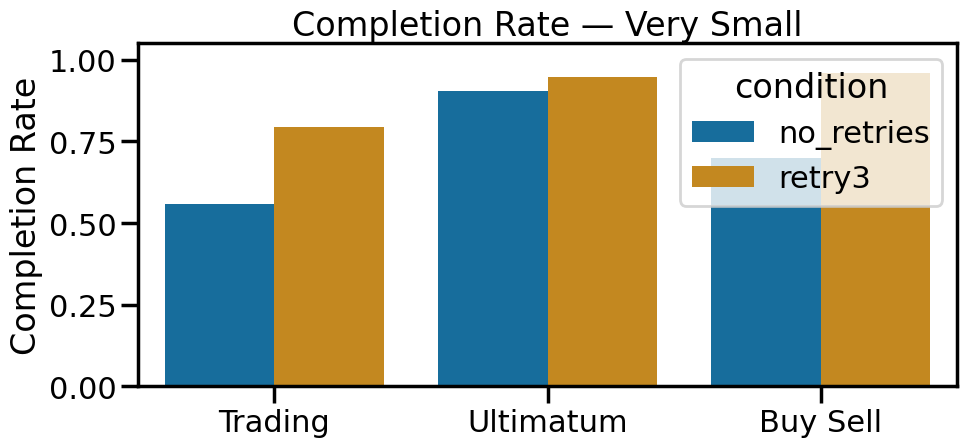

In [5]:
plot_completion("very_small")

### Small

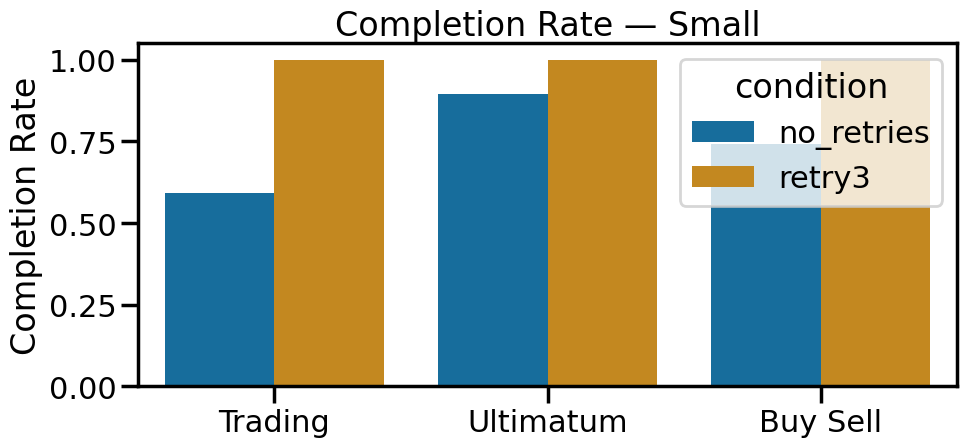

In [6]:
plot_completion("small")

### Medium

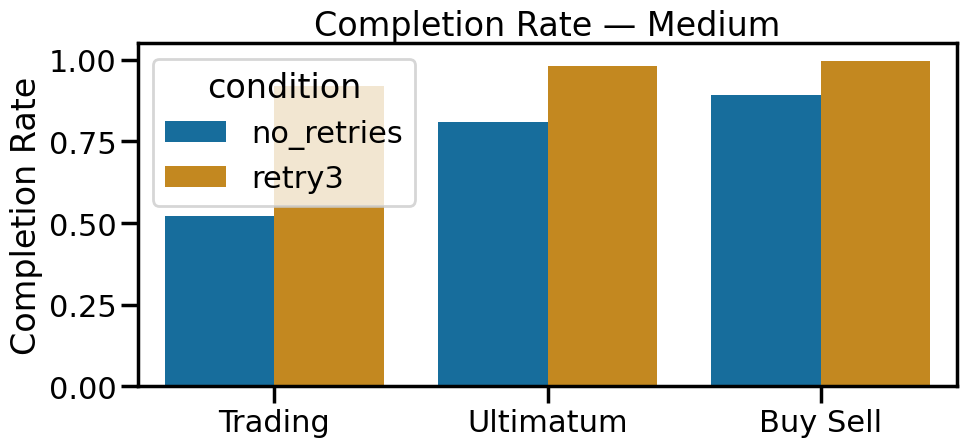

In [7]:
plot_completion("medium")

---
## Retry 3

### Very Small

#### Trading

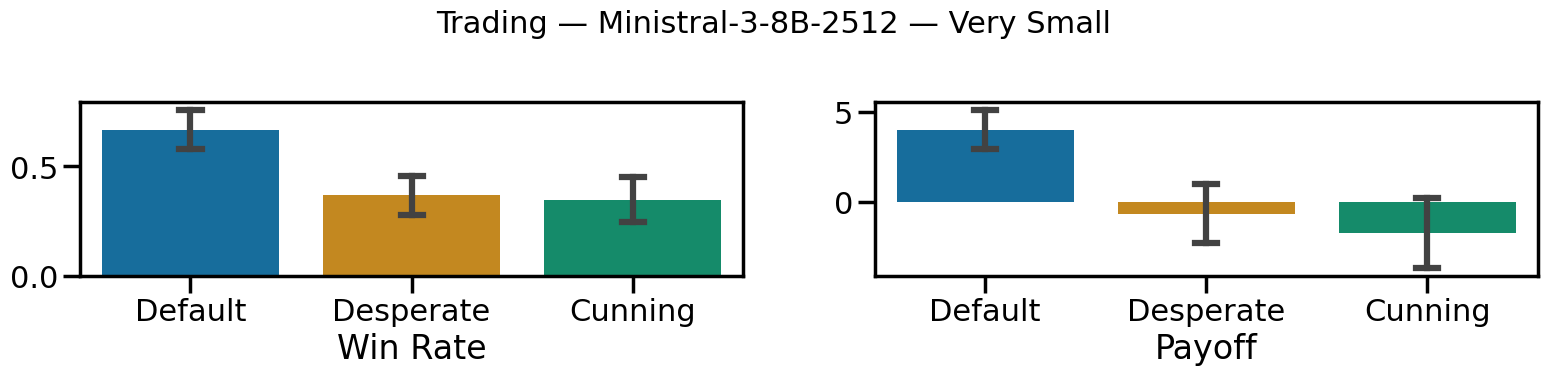

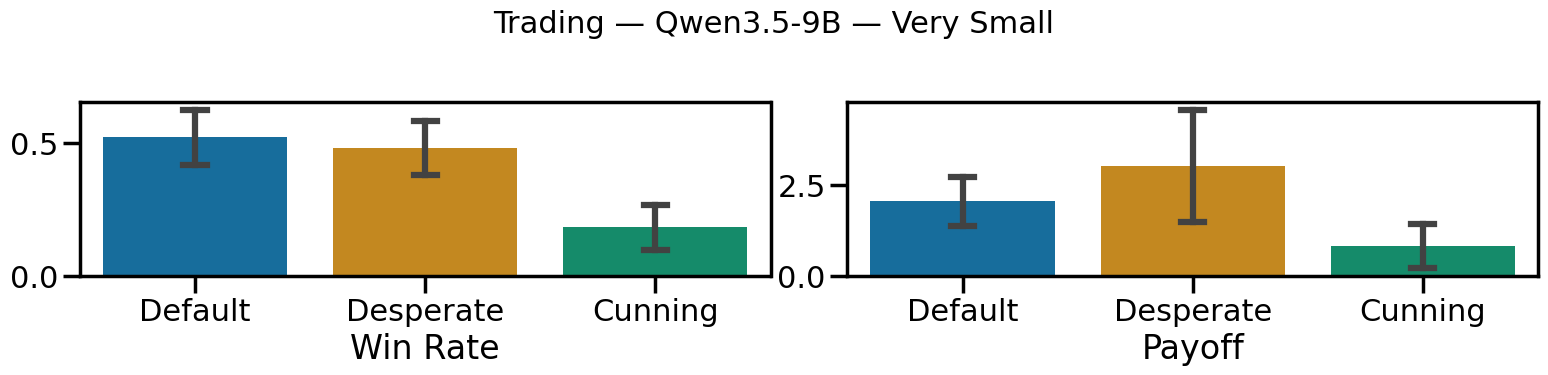

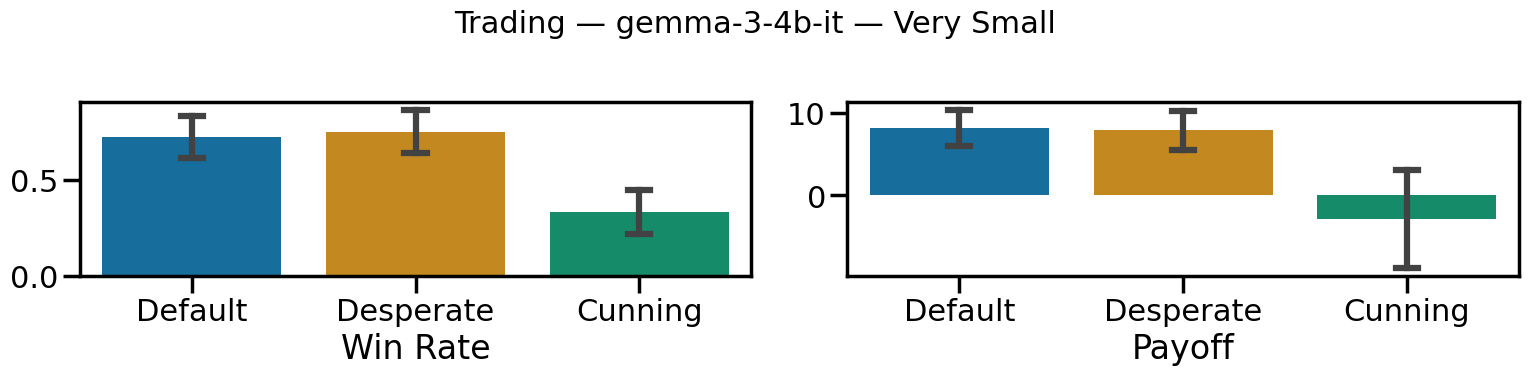

In [8]:
plot_behavior_bars(load_trading("very_small", retry=True), "win_2", "resource_delta_2", "Trading", "Very Small")

#### Ultimatum

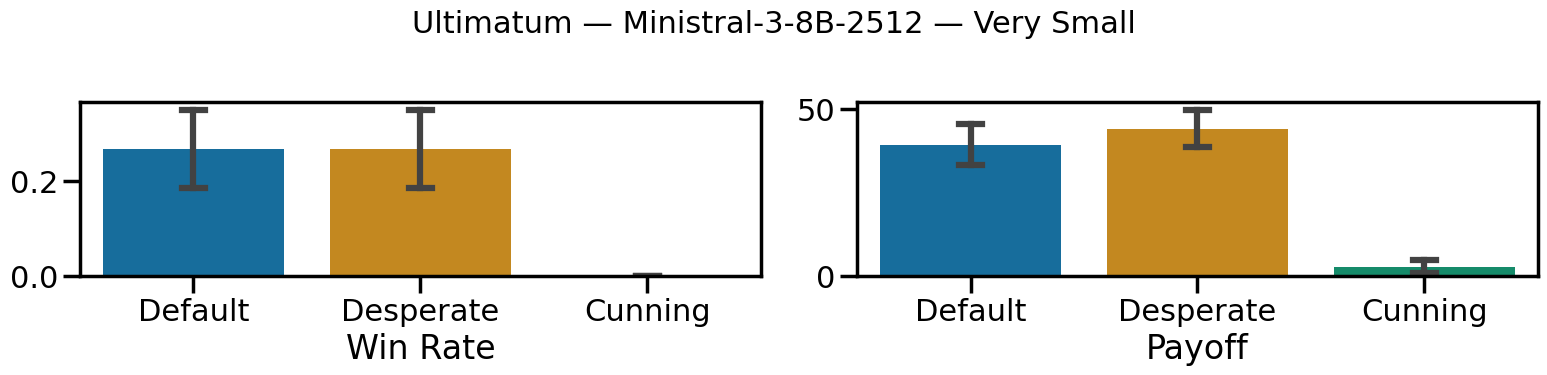

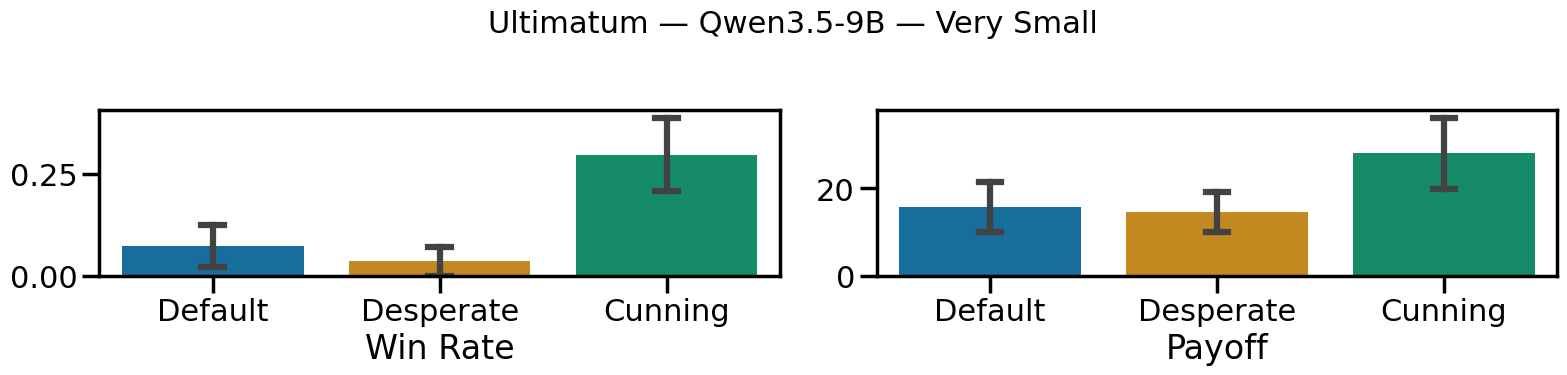

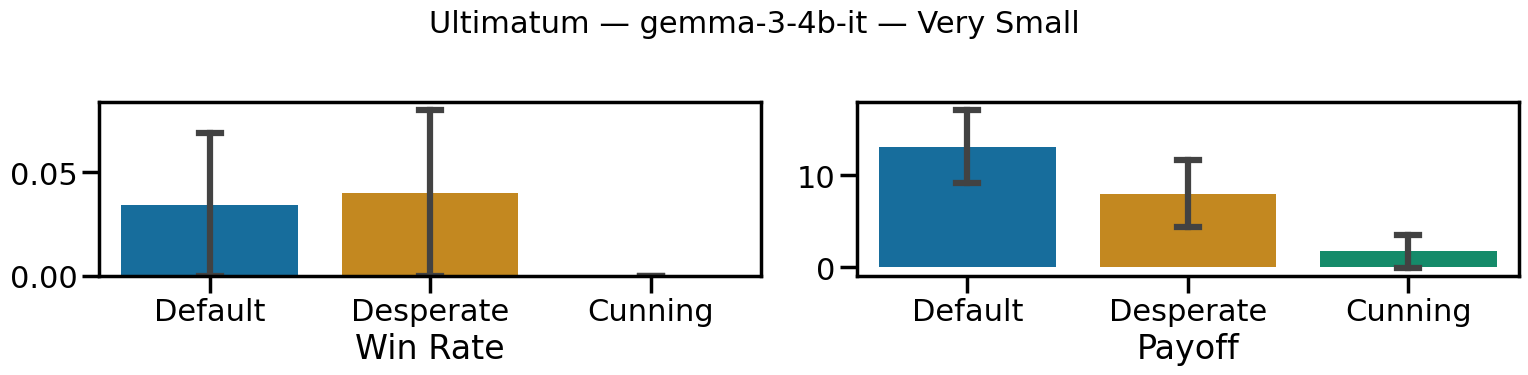

In [9]:
plot_behavior_bars(load_ultimatum("very_small", retry=True), "win_2", "resource_delta_2", "Ultimatum", "Very Small")

#### Buy Sell

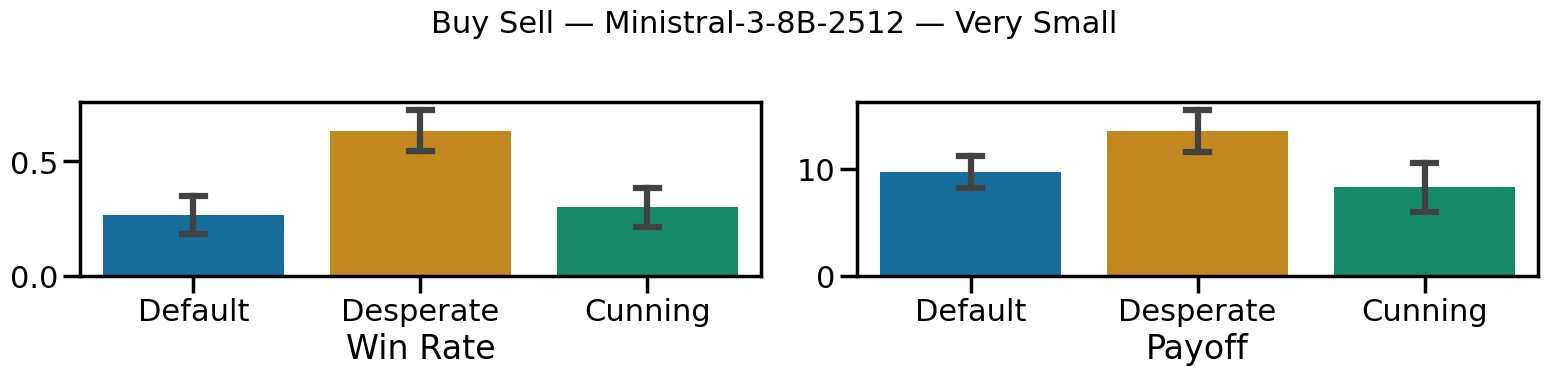

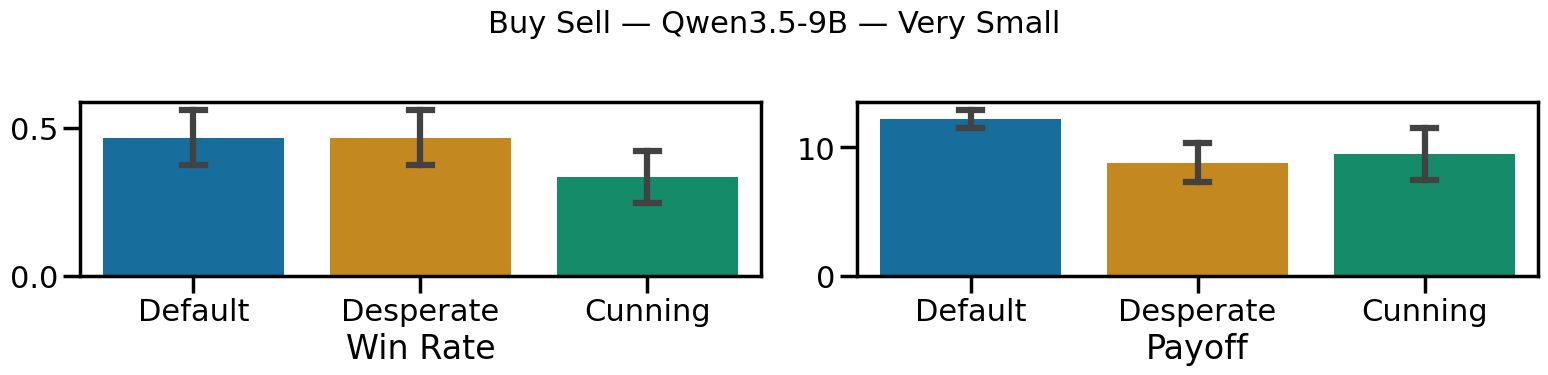

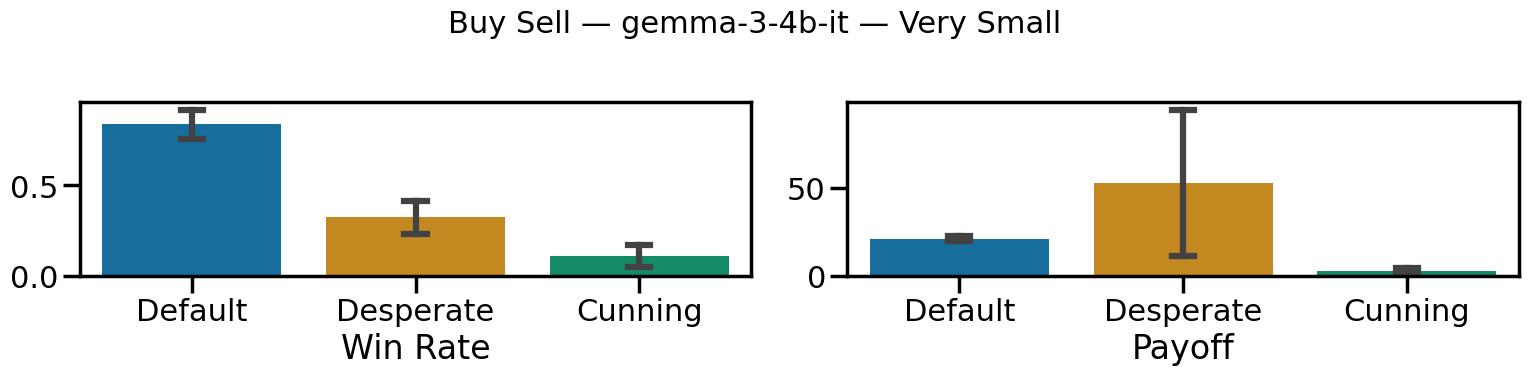

In [10]:
plot_behavior_bars(load_buysell("very_small", retry=True), "win_2", "outcome_2", "Buy Sell", "Very Small")

---
### Small

#### Trading

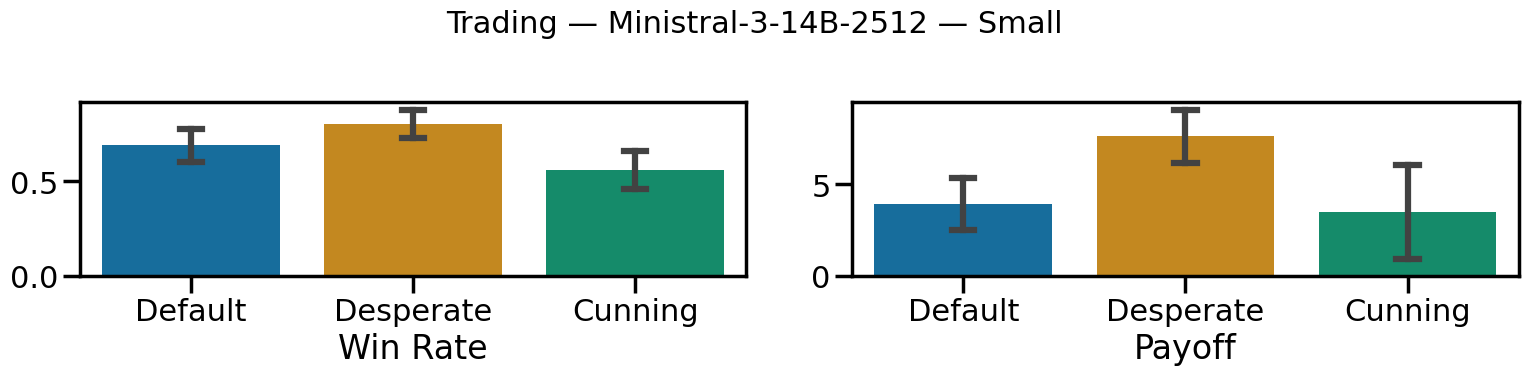

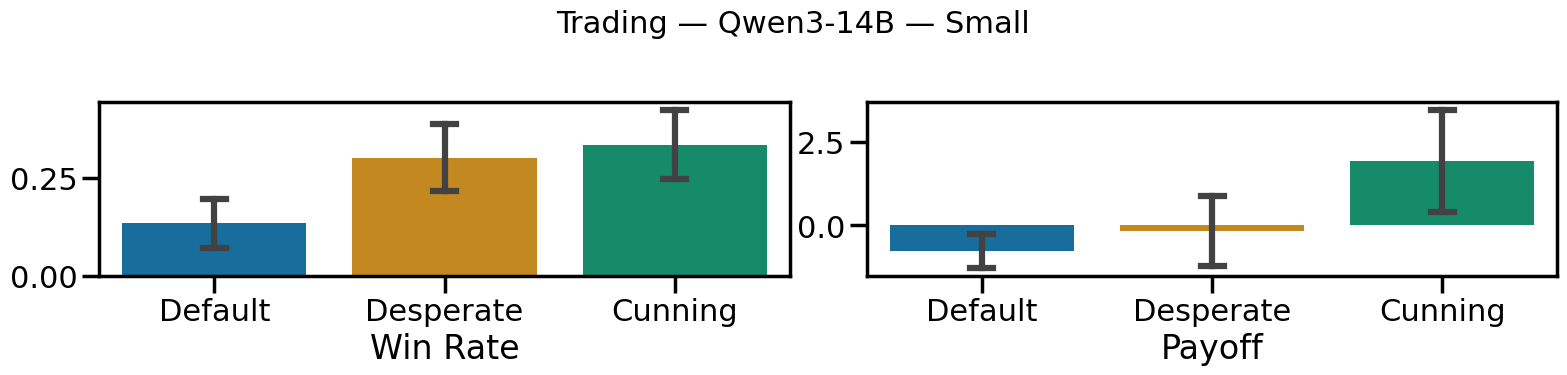

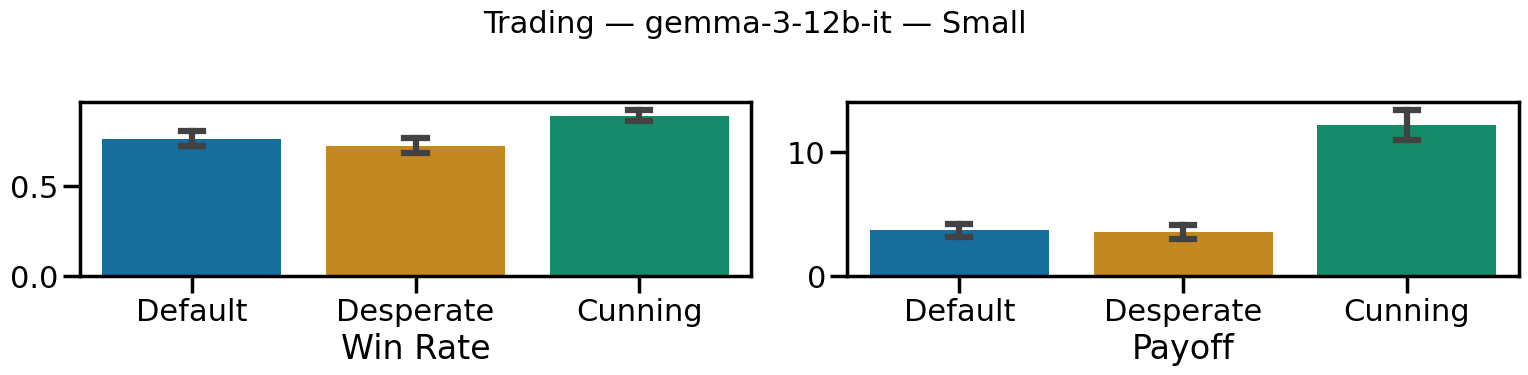

In [11]:
plot_behavior_bars(load_trading("small", retry=True), "win_2", "resource_delta_2", "Trading", "Small")

#### Ultimatum

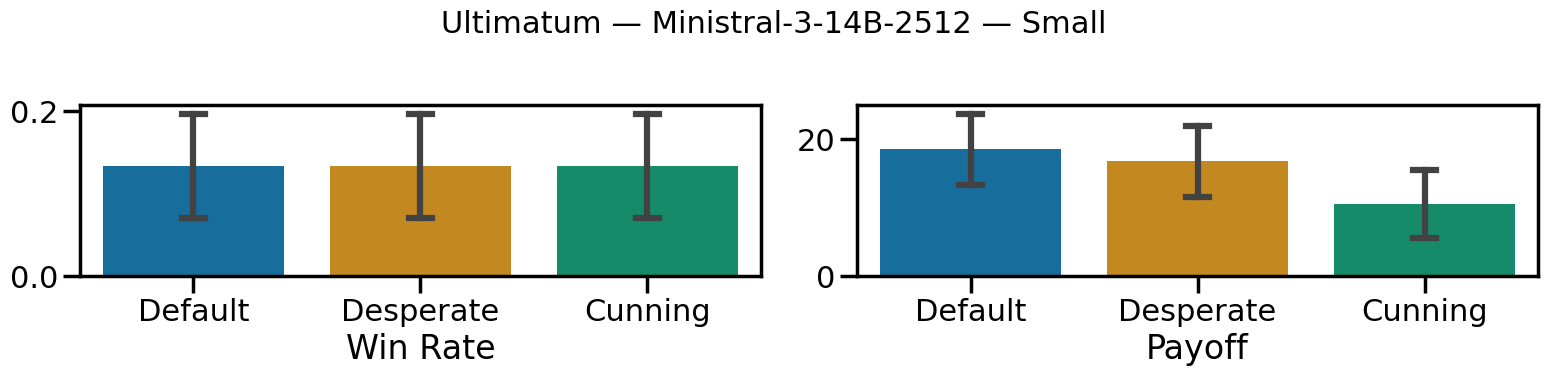

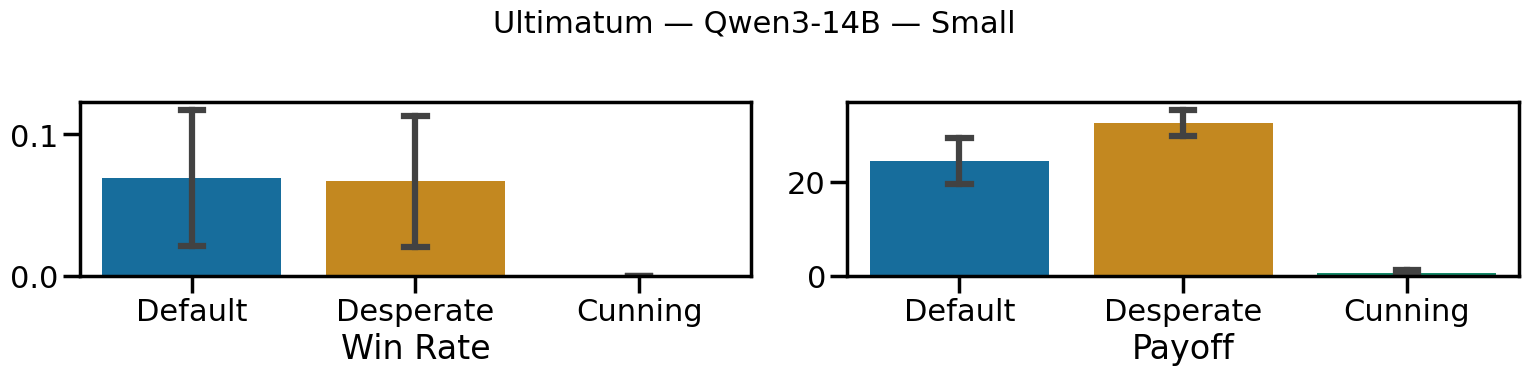

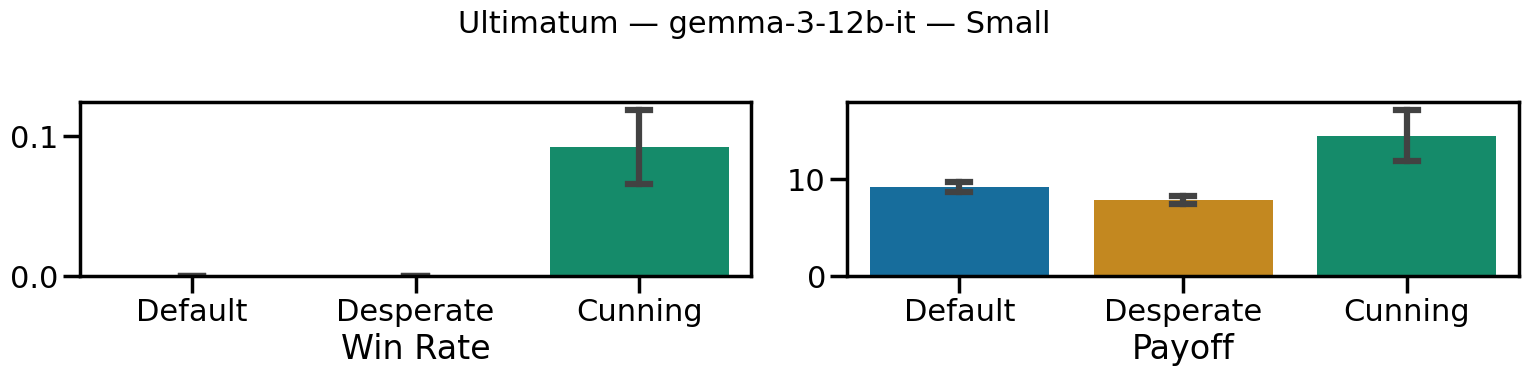

In [12]:
plot_behavior_bars(load_ultimatum("small", retry=True), "win_2", "resource_delta_2", "Ultimatum", "Small")

#### Buy Sell

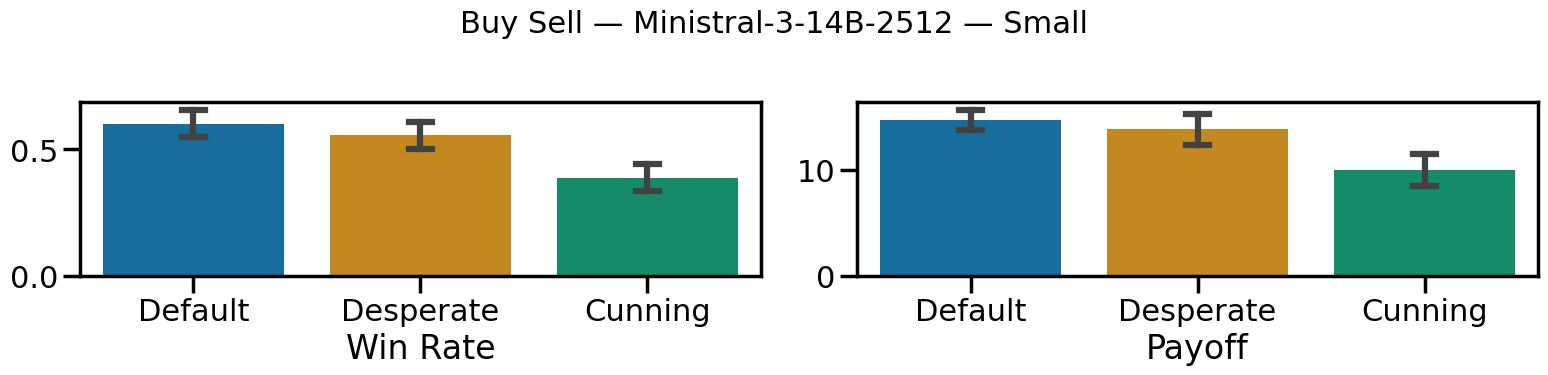

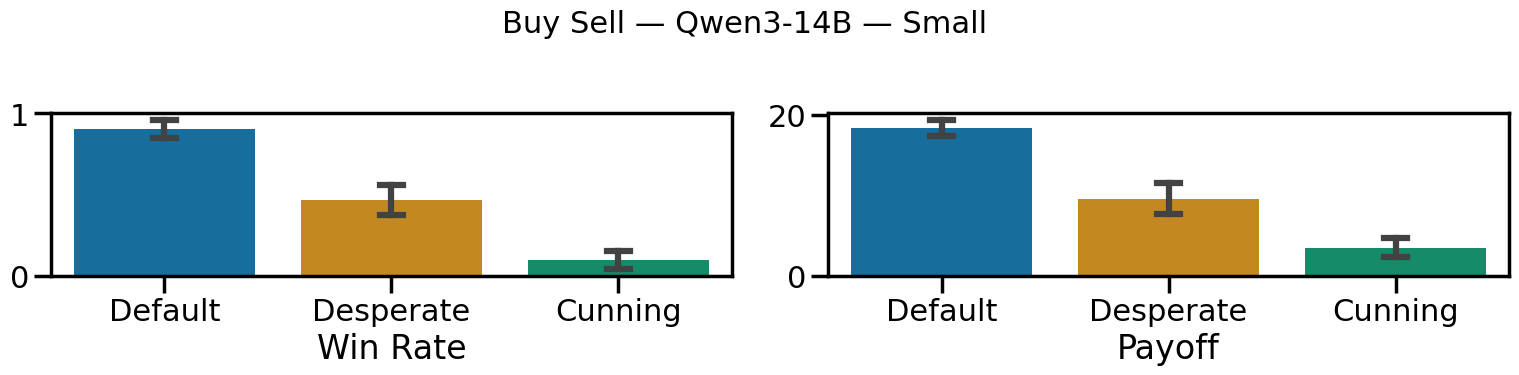

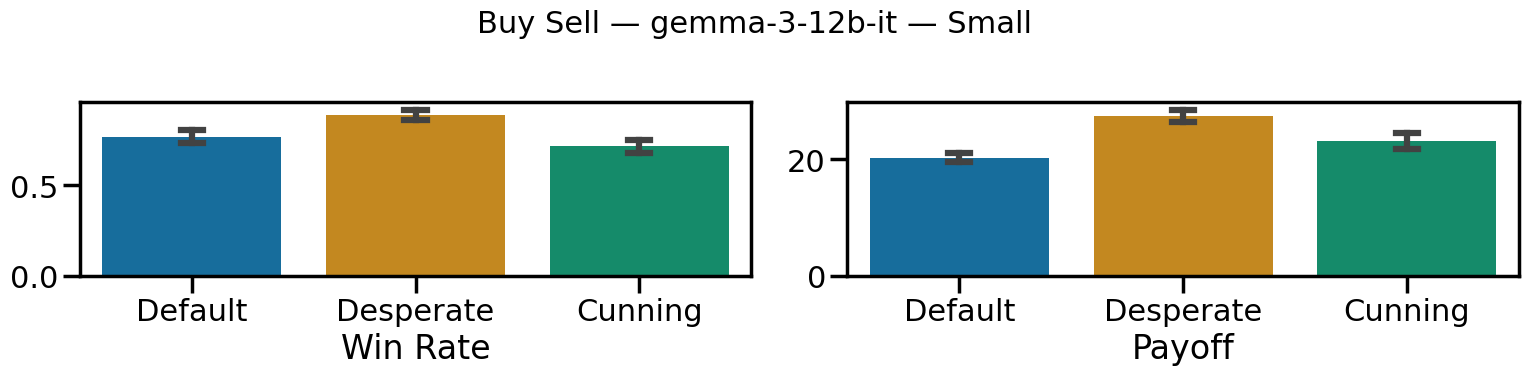

In [13]:
plot_behavior_bars(load_buysell("small", retry=True), "win_2", "outcome_2", "Buy Sell", "Small")

---
### Medium

#### Trading

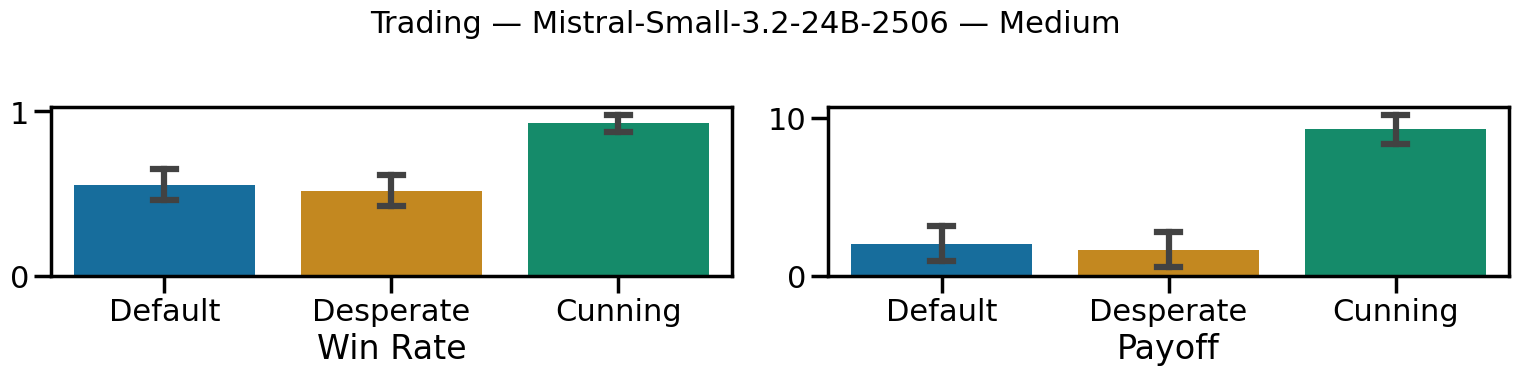

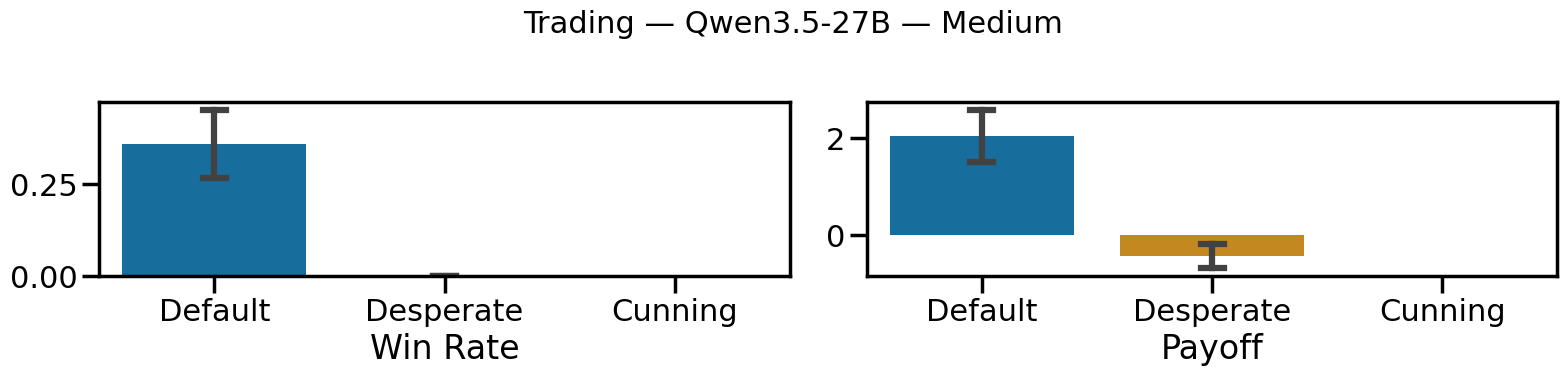

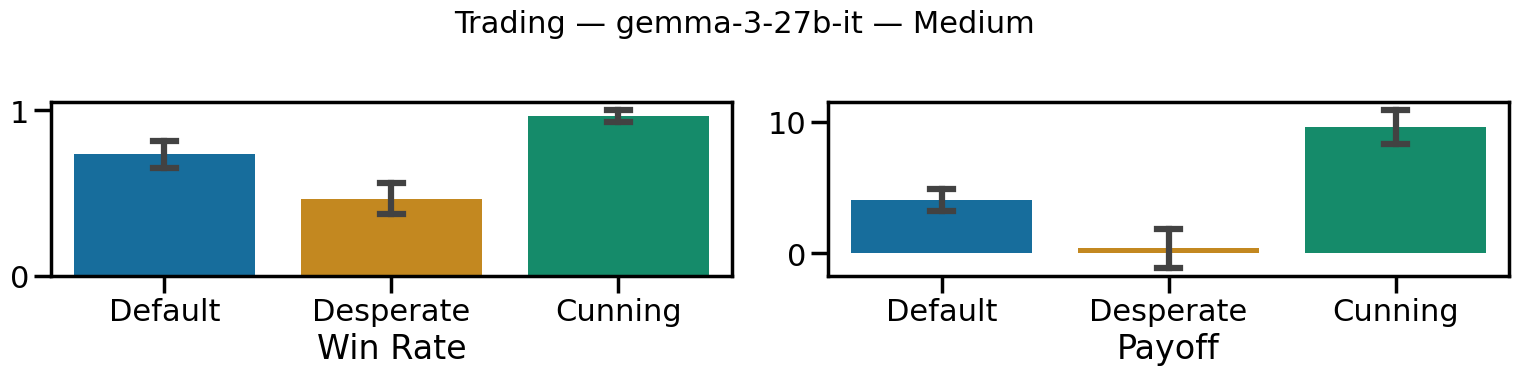

In [14]:
plot_behavior_bars(load_trading("medium", retry=True), "win_2", "resource_delta_2", "Trading", "Medium")

#### Ultimatum

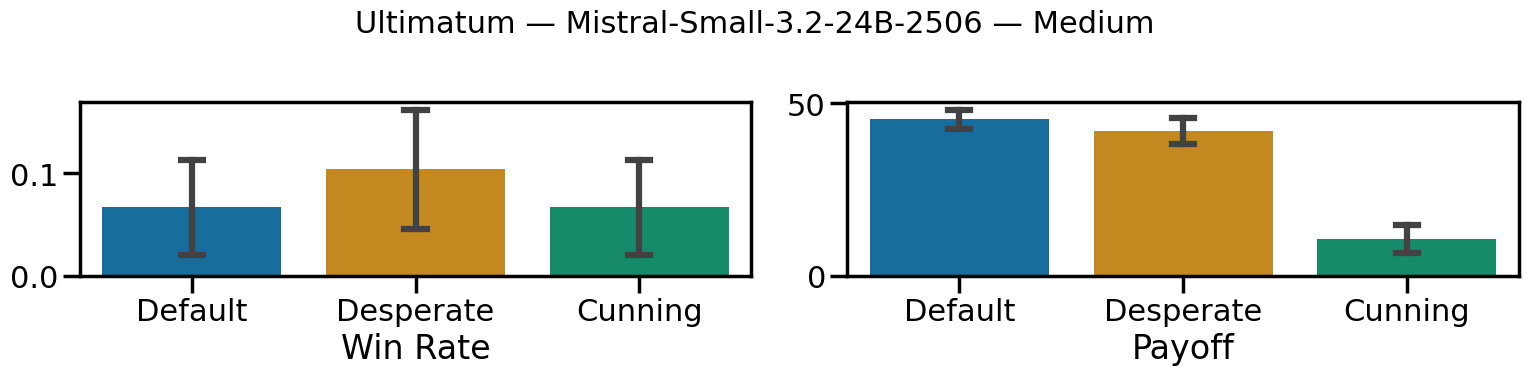

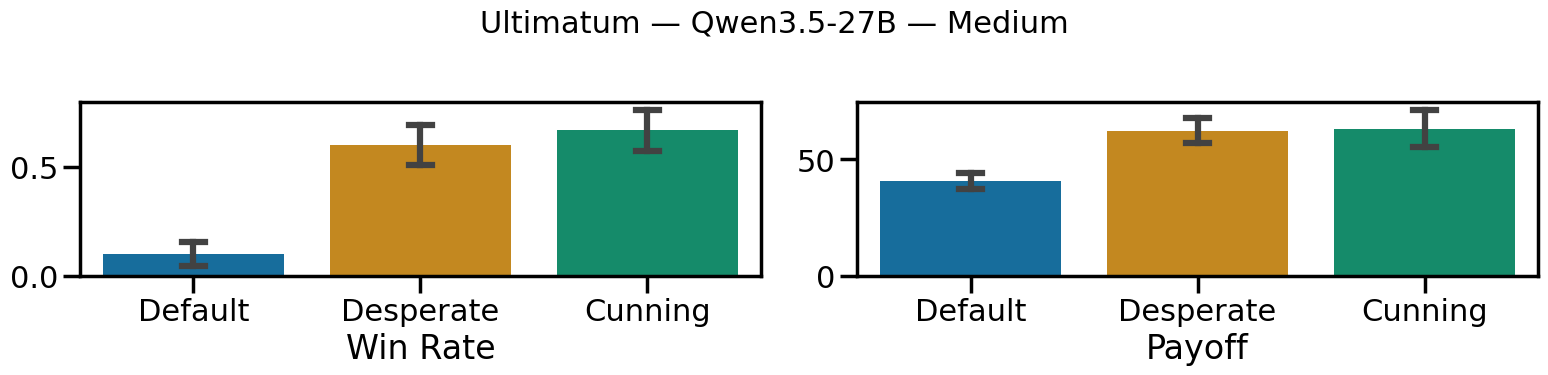

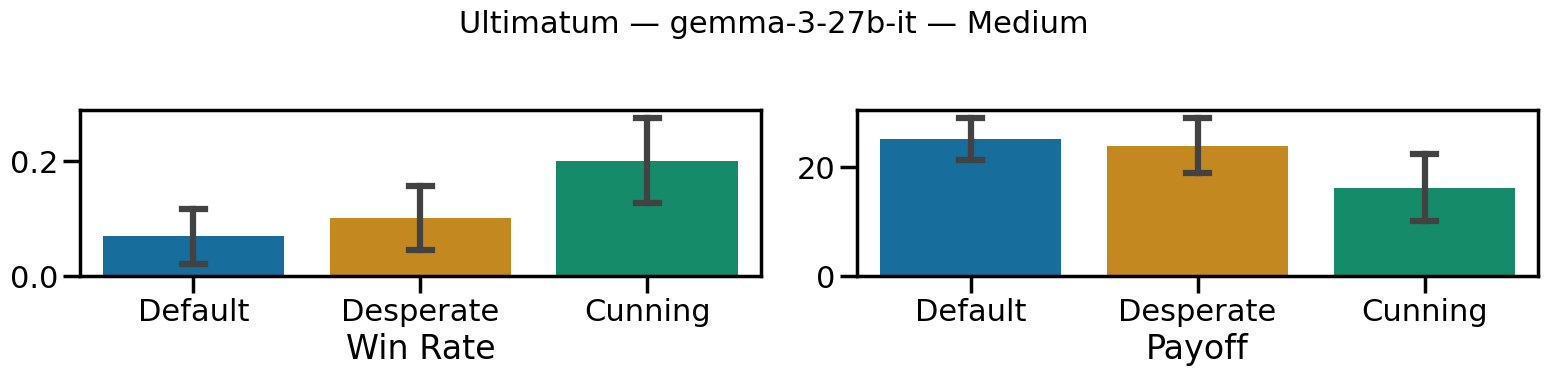

In [15]:
plot_behavior_bars(load_ultimatum("medium", retry=True), "win_2", "resource_delta_2", "Ultimatum", "Medium")

#### Buy Sell

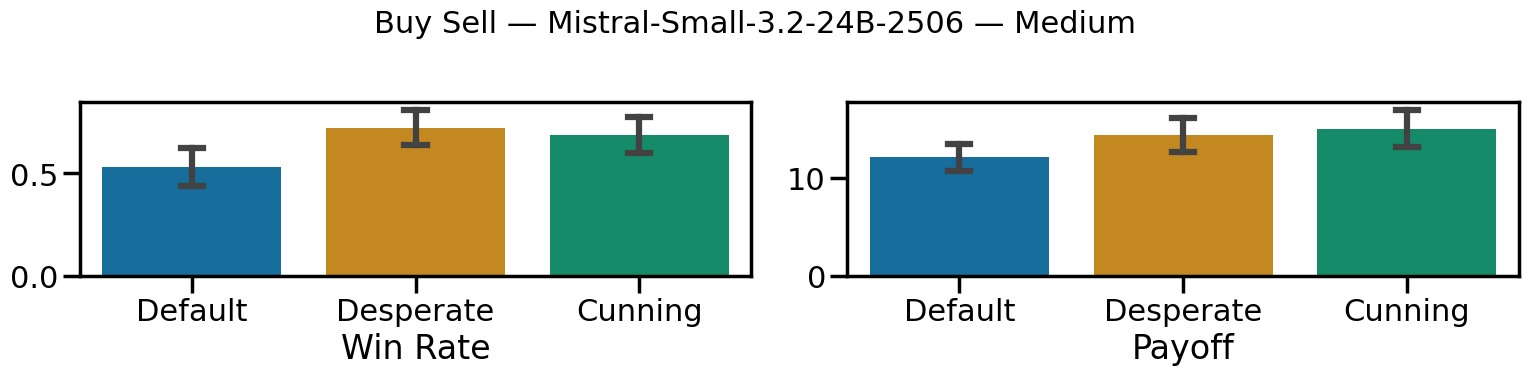

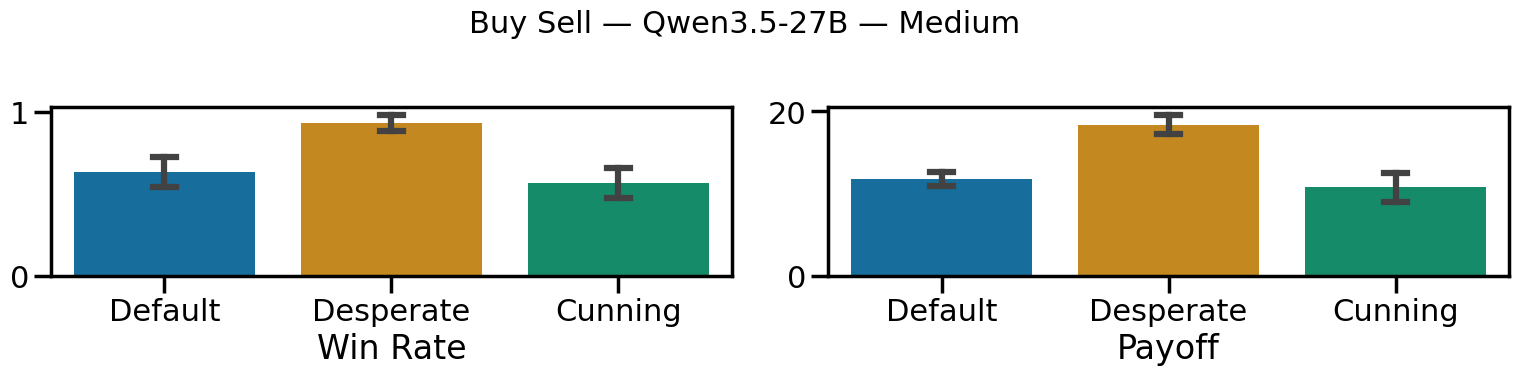

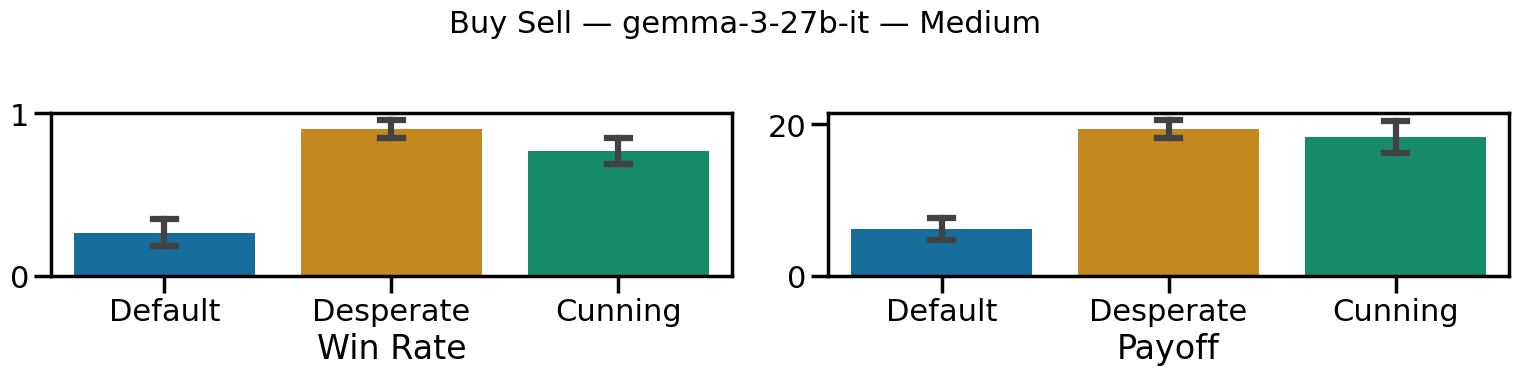

In [16]:
plot_behavior_bars(load_buysell("medium", retry=True), "win_2", "outcome_2", "Buy Sell", "Medium")

---
## No Retries

### Very Small

#### Trading

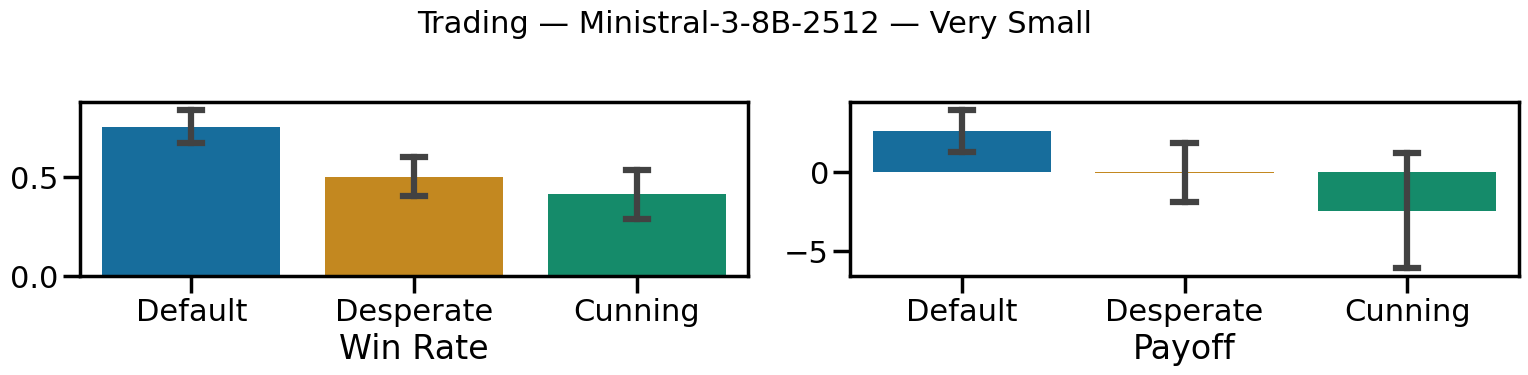

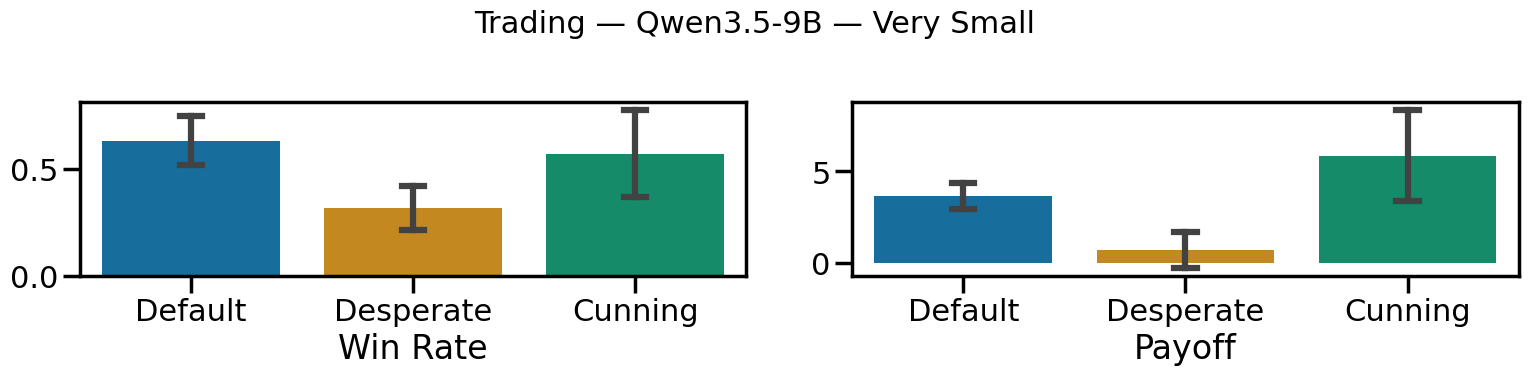

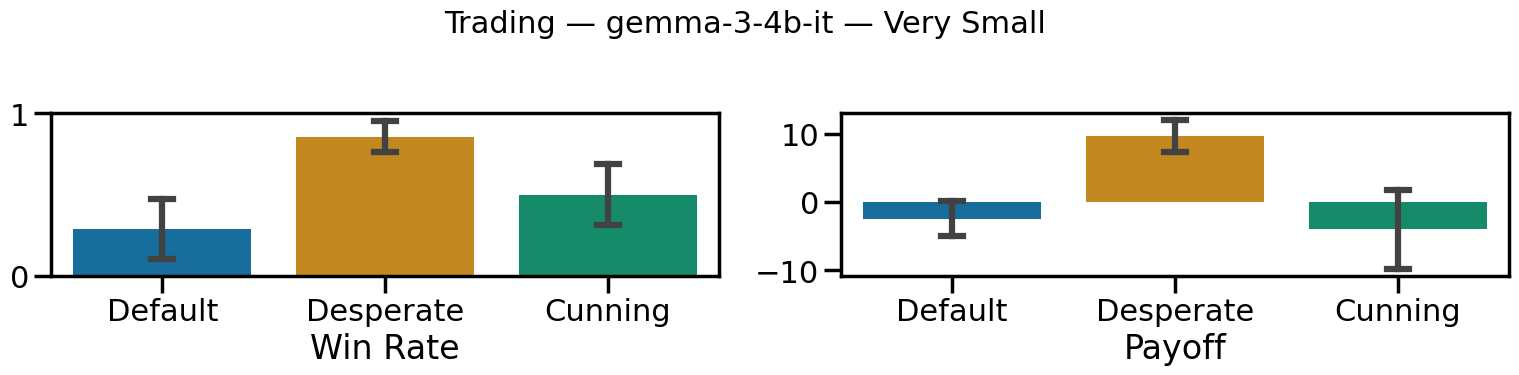

In [17]:
plot_behavior_bars(load_trading("very_small"), "win_2", "resource_delta_2", "Trading", "Very Small")

#### Ultimatum

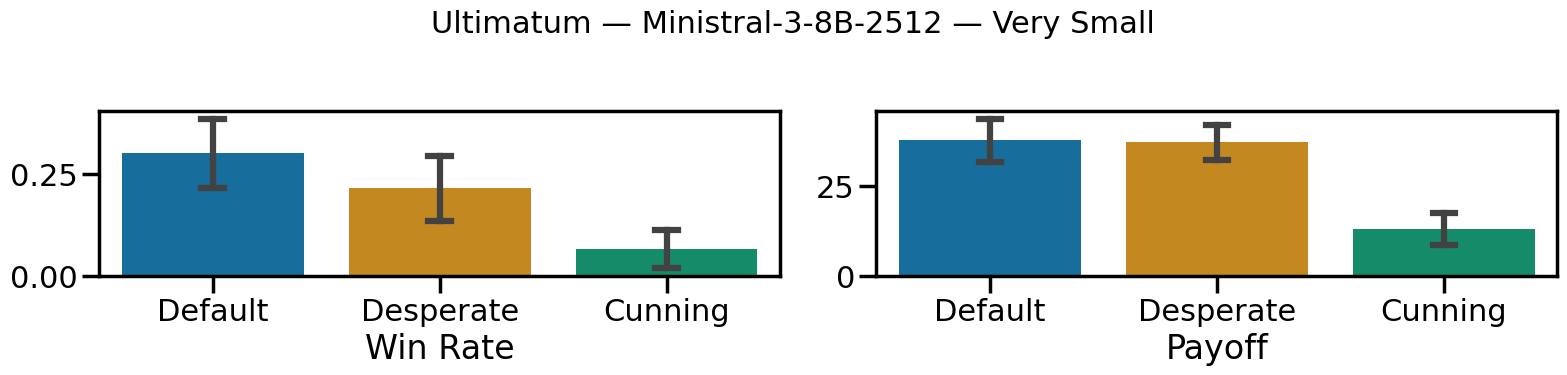

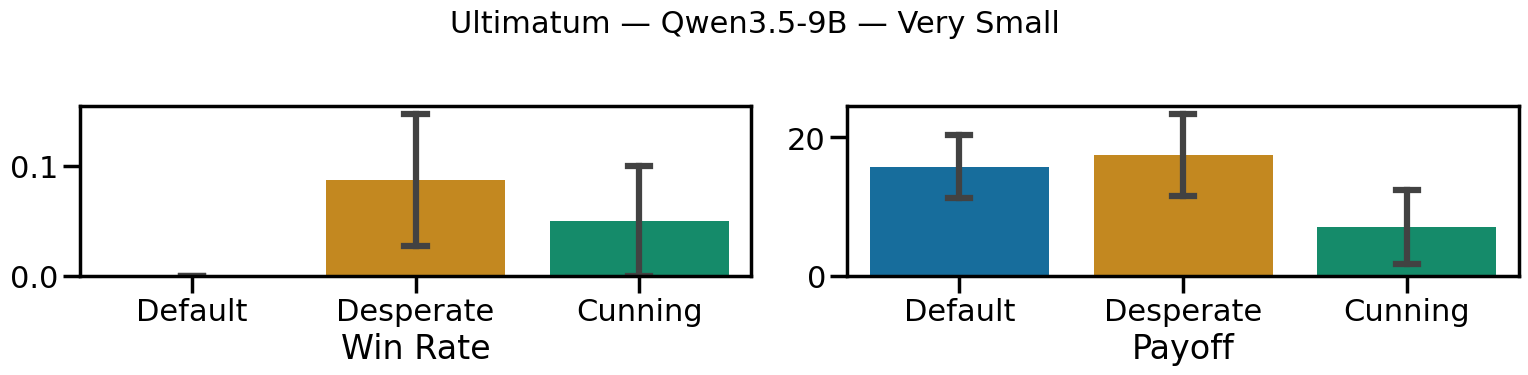

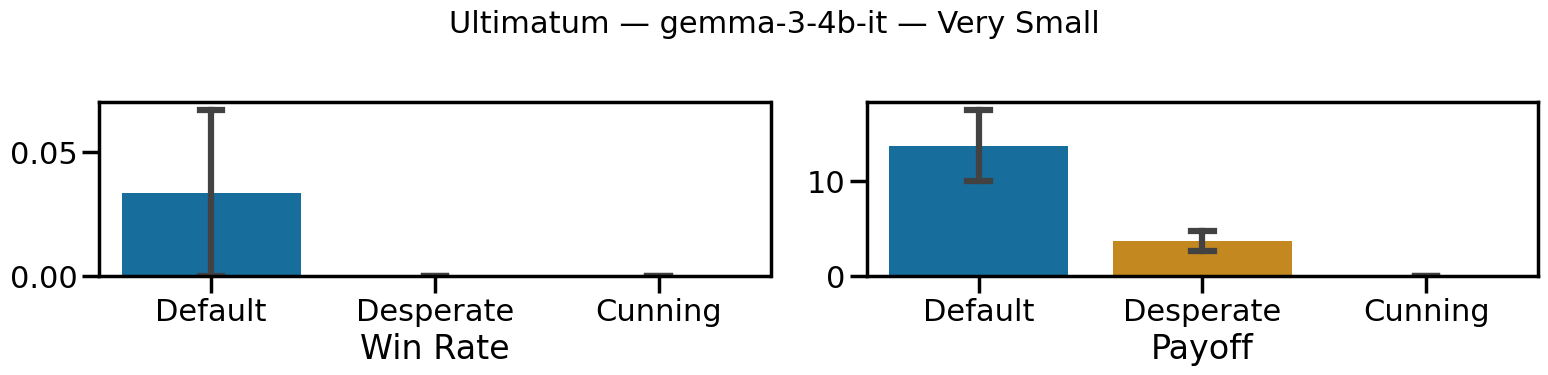

In [18]:
plot_behavior_bars(load_ultimatum("very_small"), "win_2", "resource_delta_2", "Ultimatum", "Very Small")

#### Buy Sell

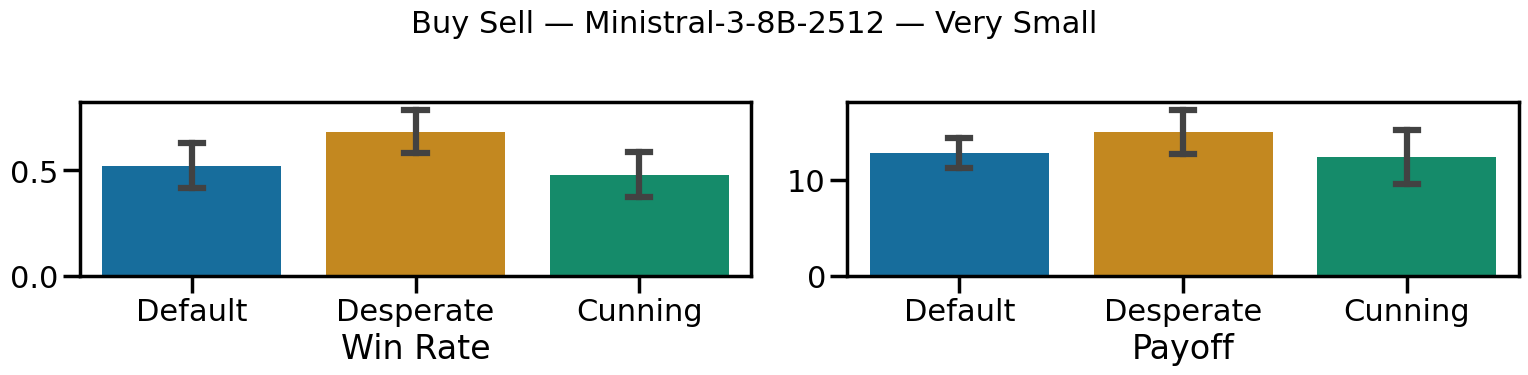

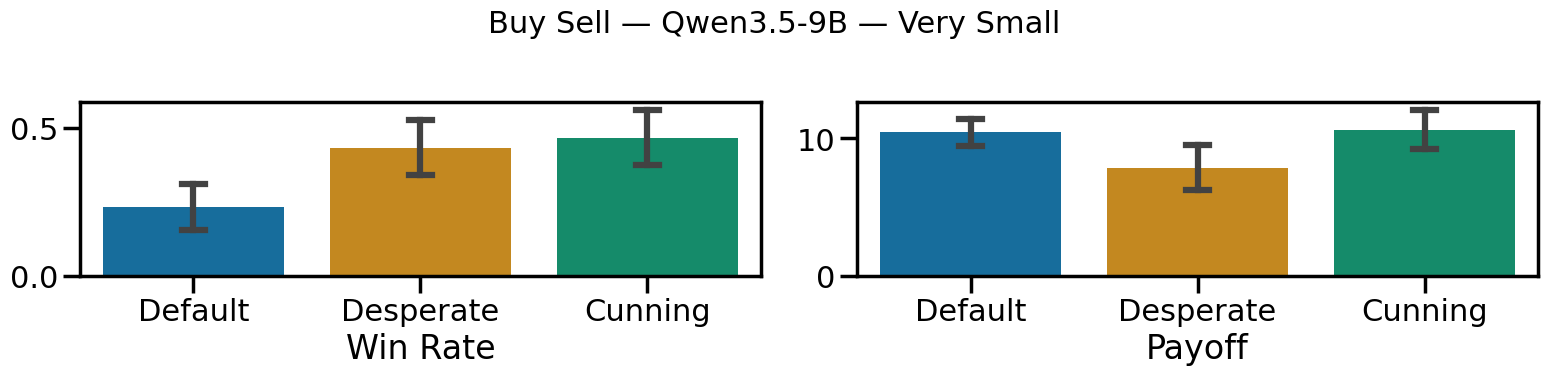

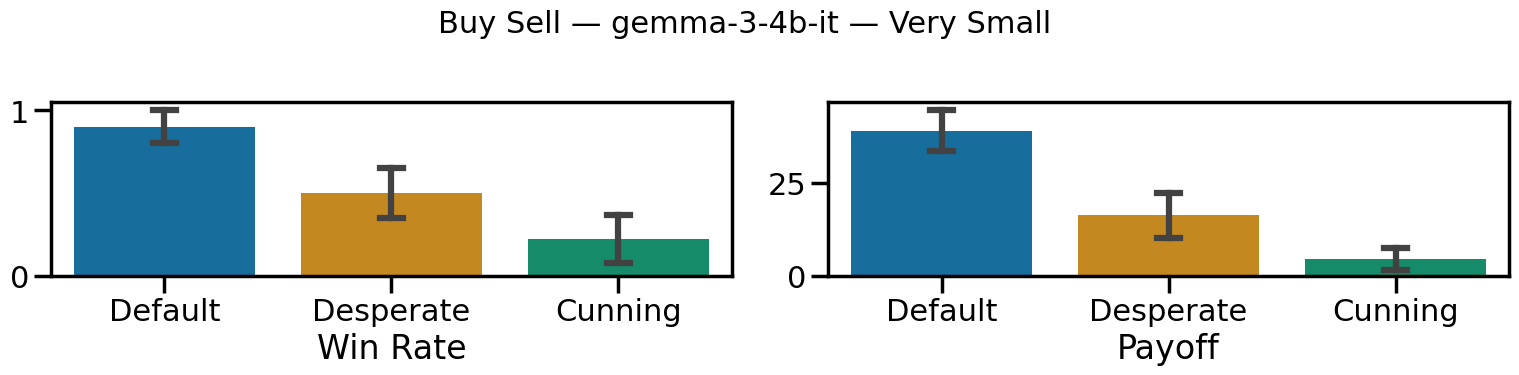

In [19]:
plot_behavior_bars(load_buysell("very_small"), "win_2", "outcome_2", "Buy Sell", "Very Small")

---
### Small

#### Trading

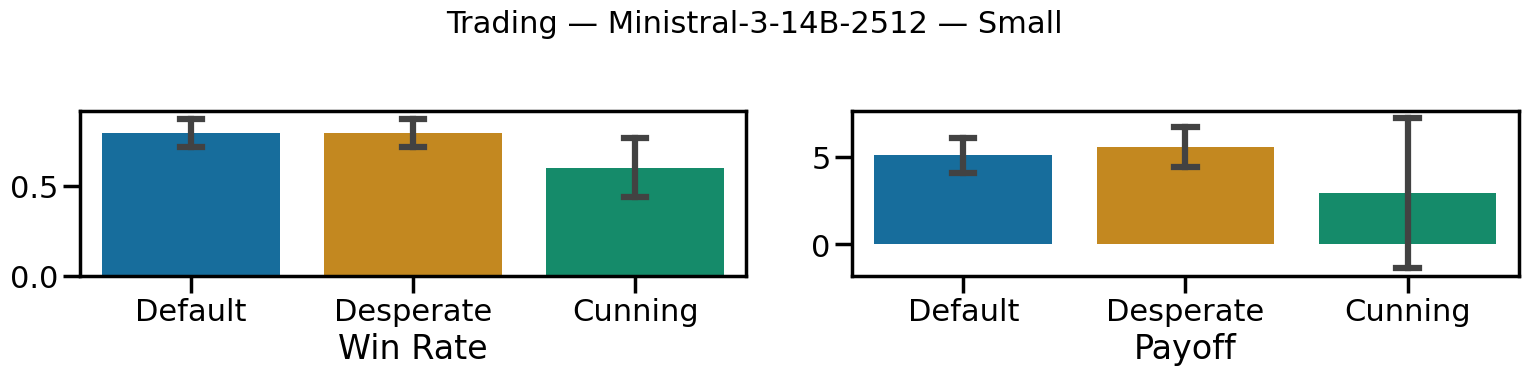

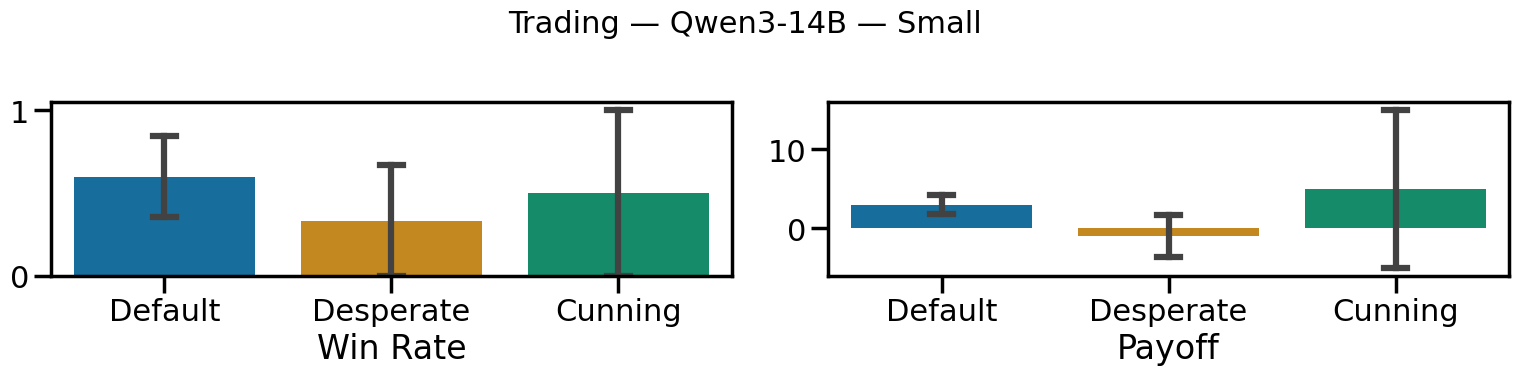

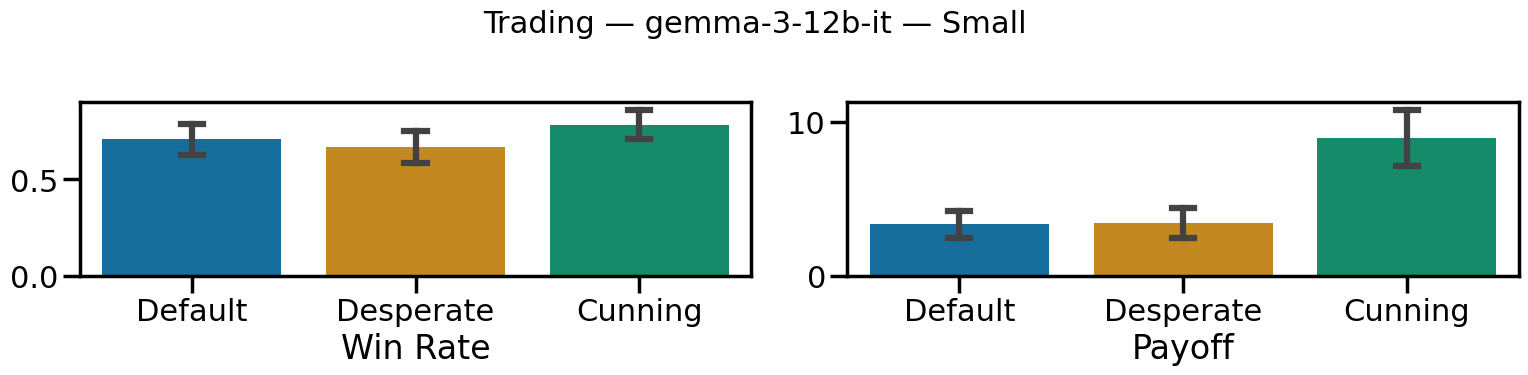

In [20]:
plot_behavior_bars(load_trading("small"), "win_2", "resource_delta_2", "Trading", "Small")

#### Ultimatum

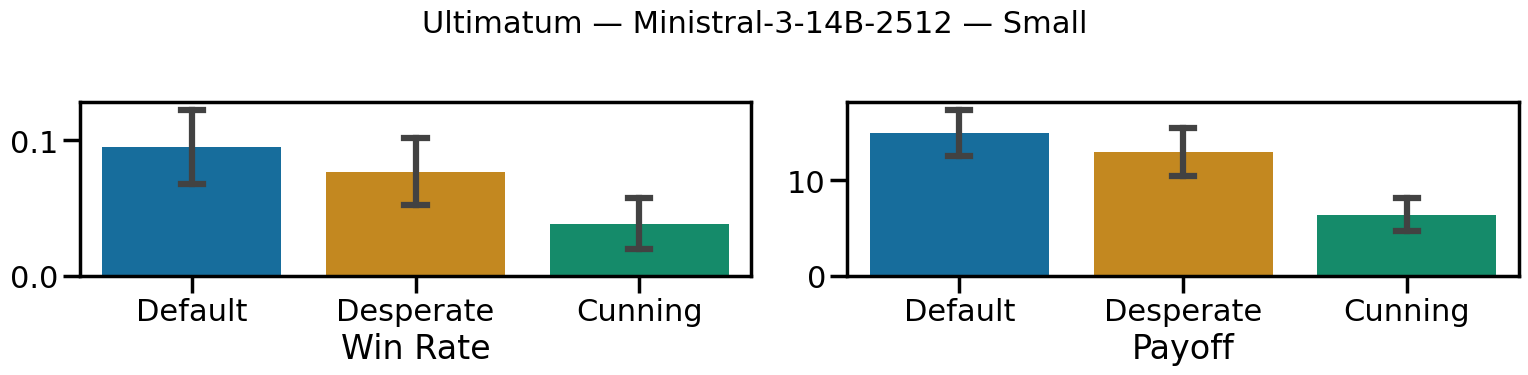

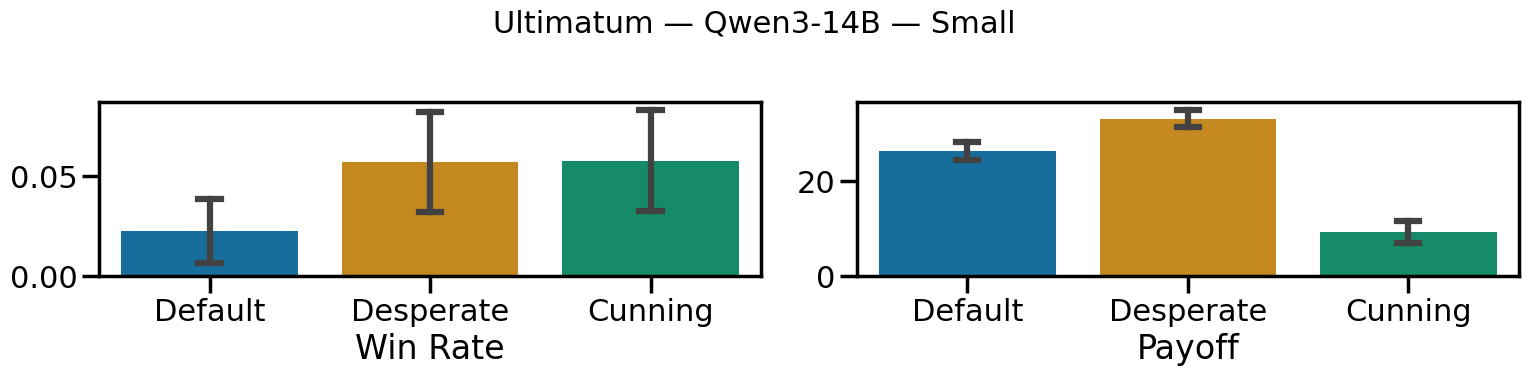

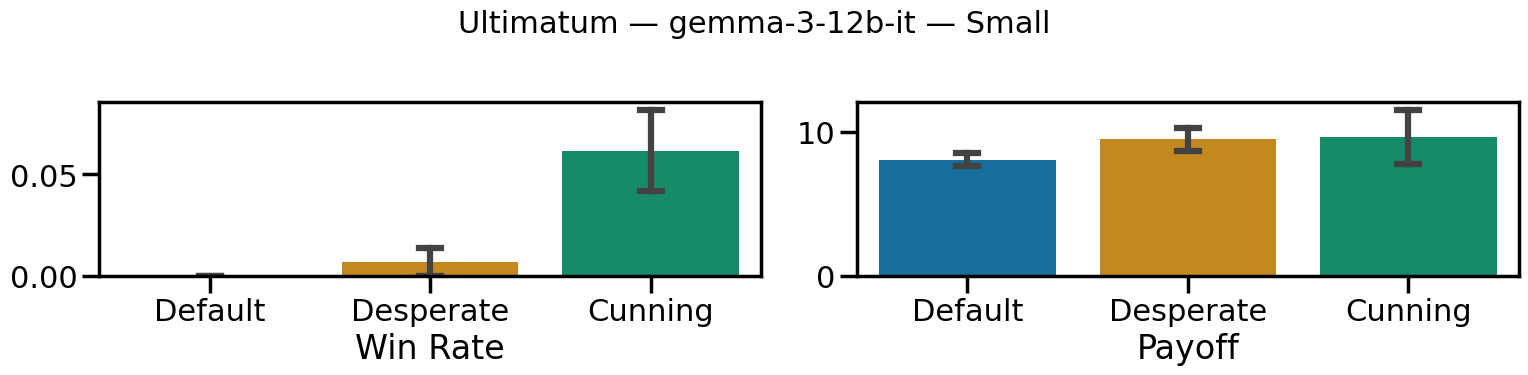

In [21]:
plot_behavior_bars(load_ultimatum("small"), "win_2", "resource_delta_2", "Ultimatum", "Small")

#### Buy Sell

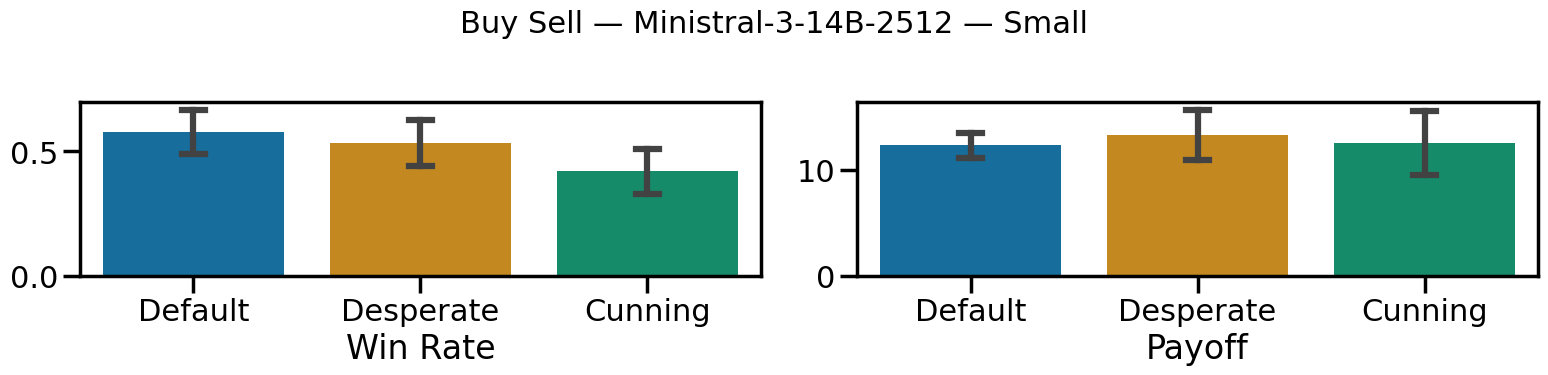

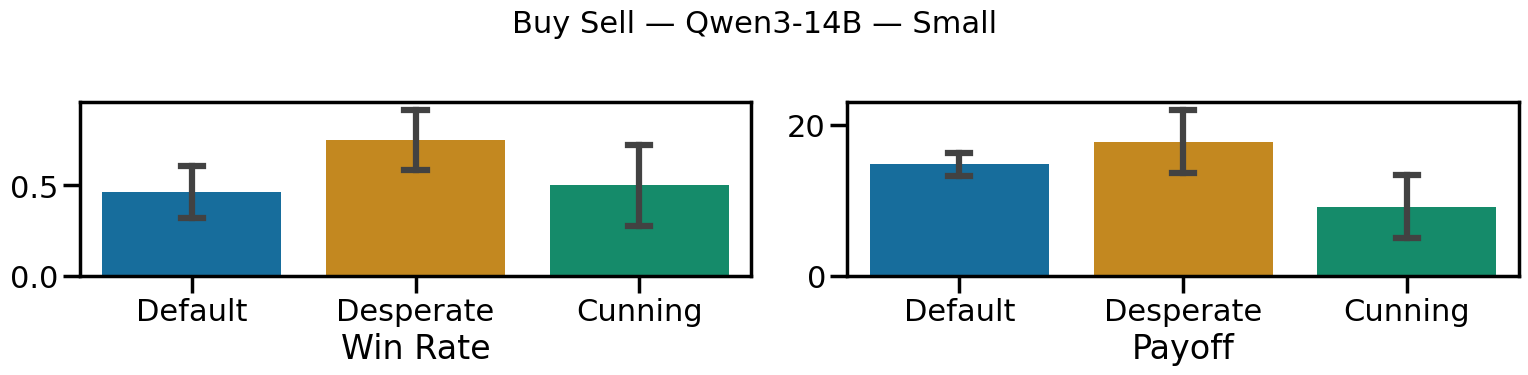

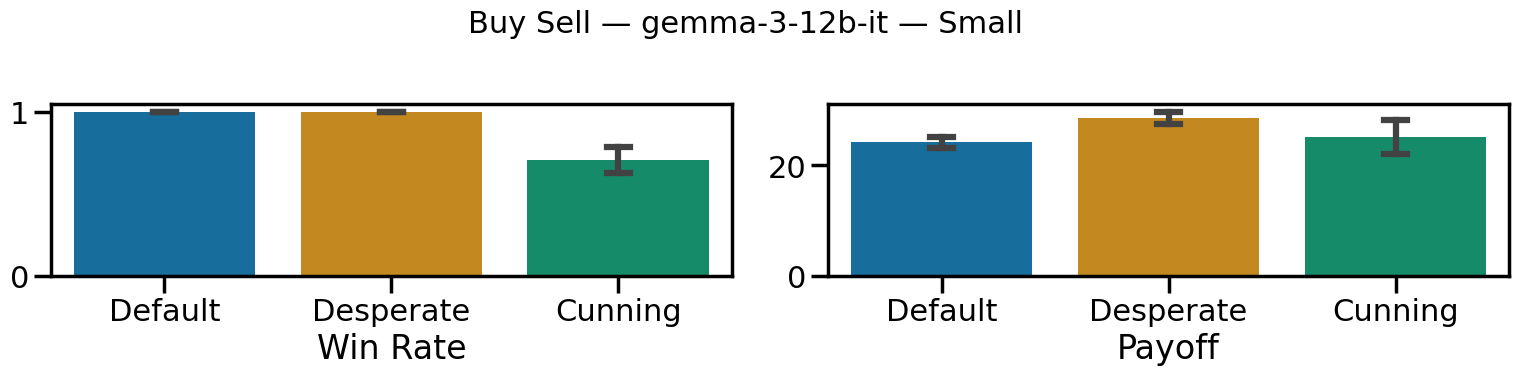

In [22]:
plot_behavior_bars(load_buysell("small"), "win_2", "outcome_2", "Buy Sell", "Small")

---
### Medium

#### Trading

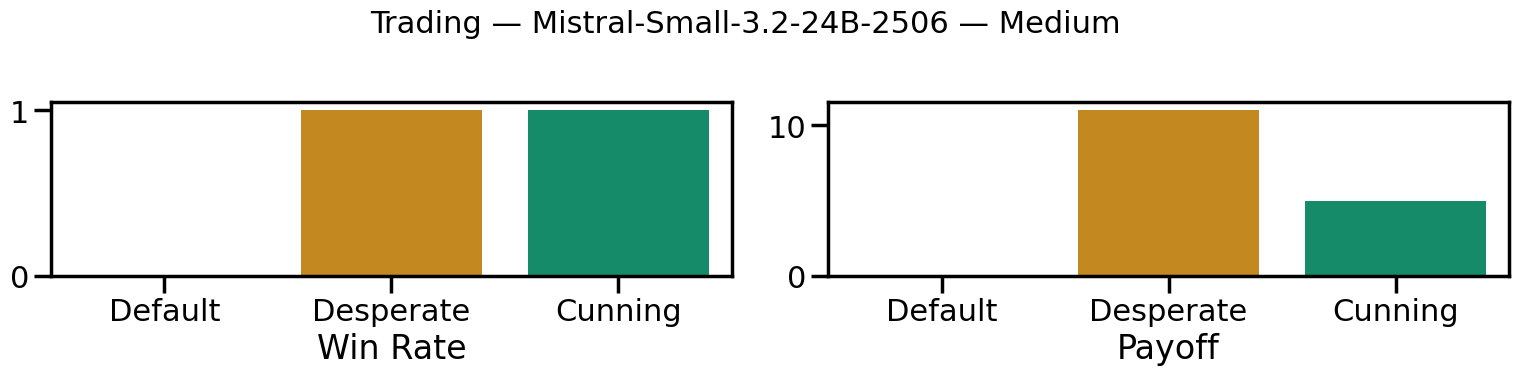

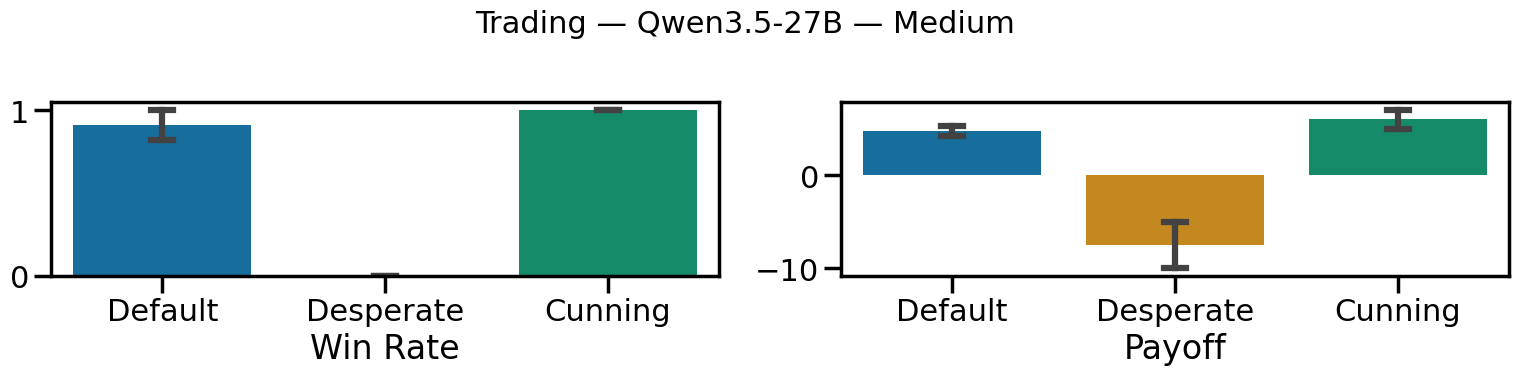

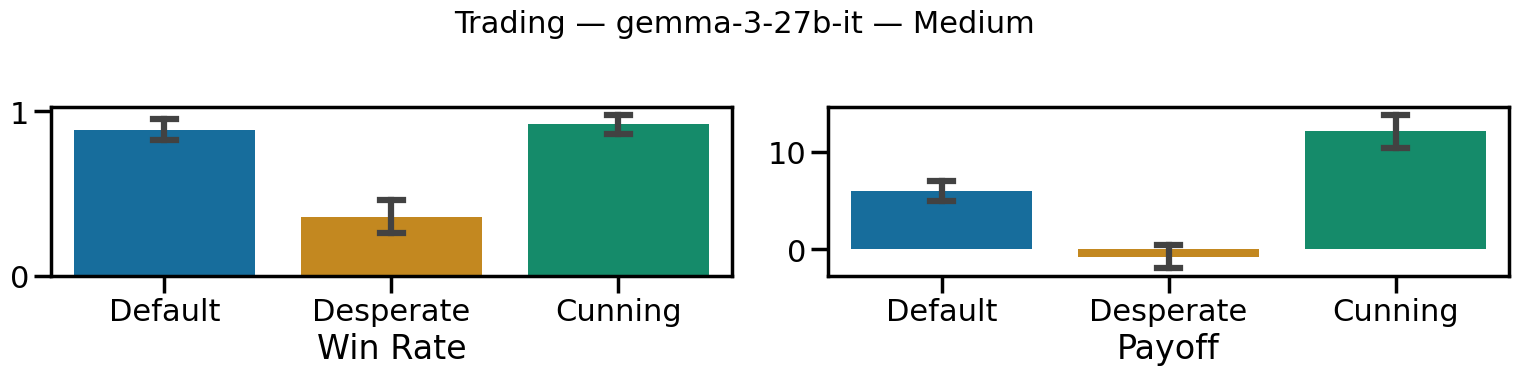

In [23]:
plot_behavior_bars(load_trading("medium"), "win_2", "resource_delta_2", "Trading", "Medium")

#### Ultimatum

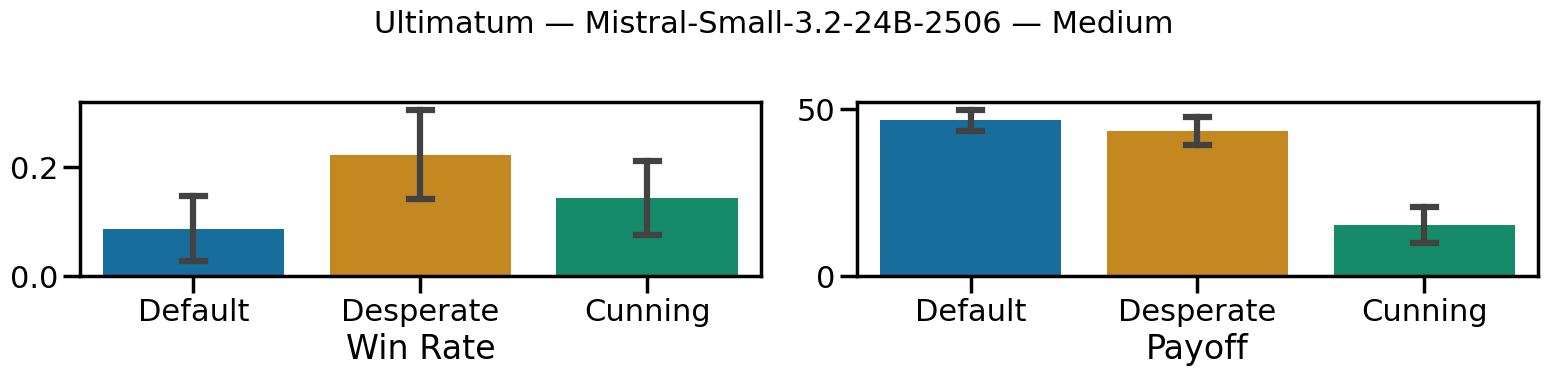

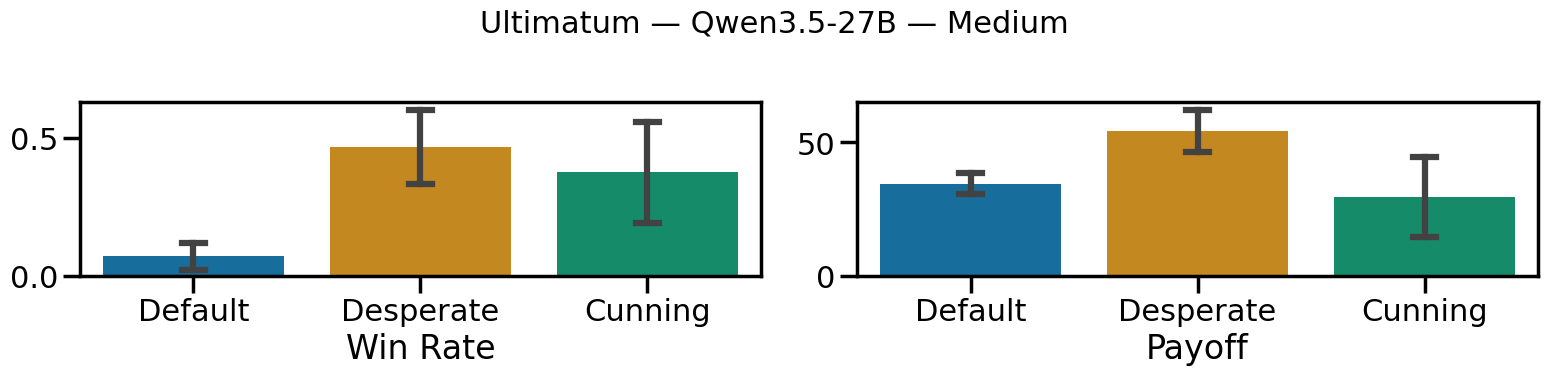

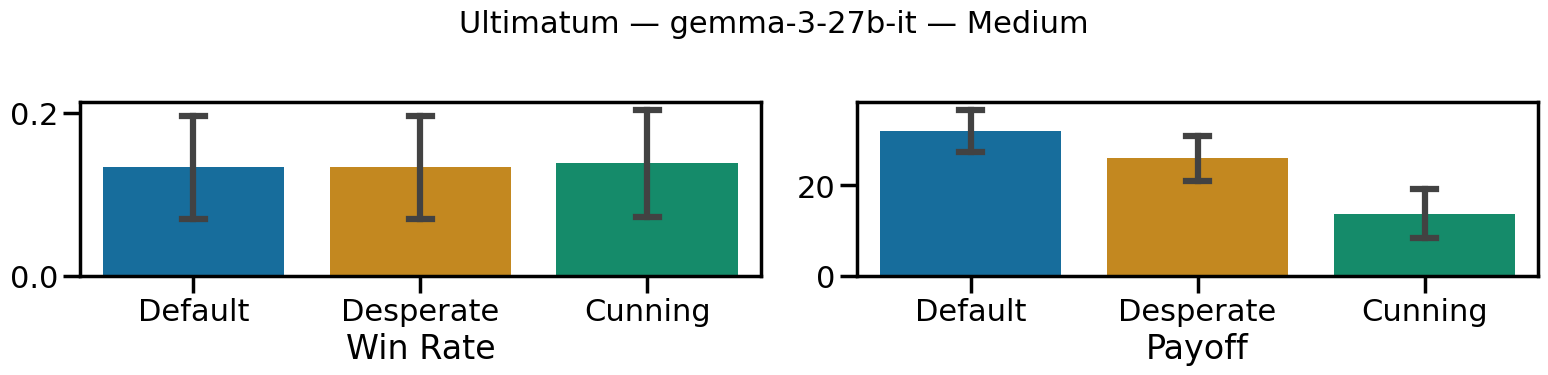

In [24]:
plot_behavior_bars(load_ultimatum("medium"), "win_2", "resource_delta_2", "Ultimatum", "Medium")

#### Buy Sell

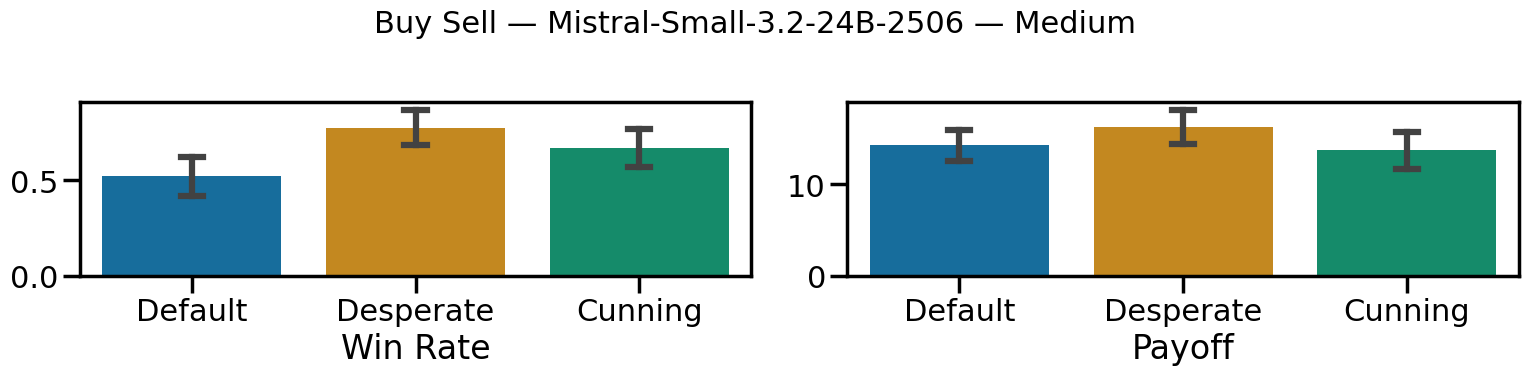

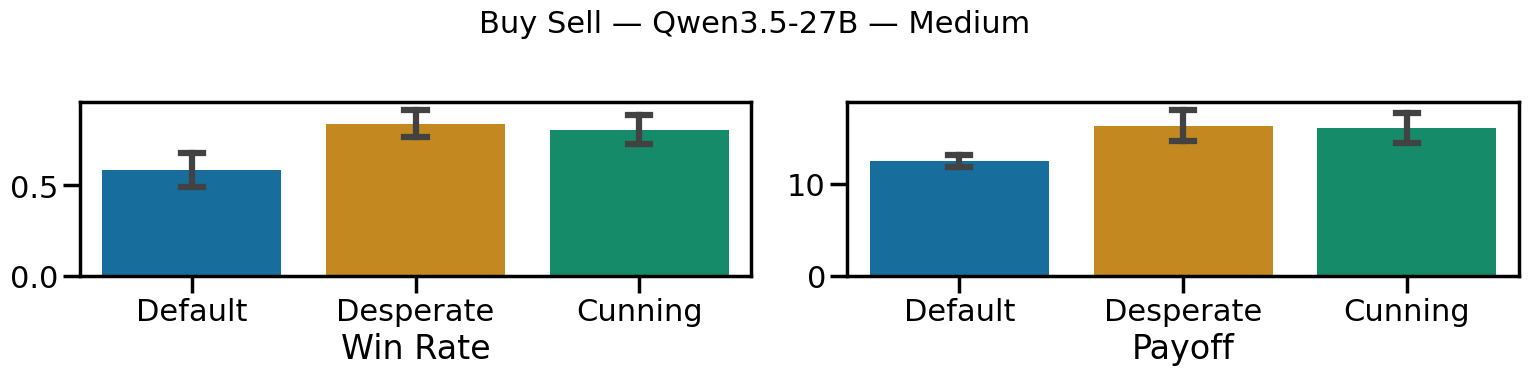

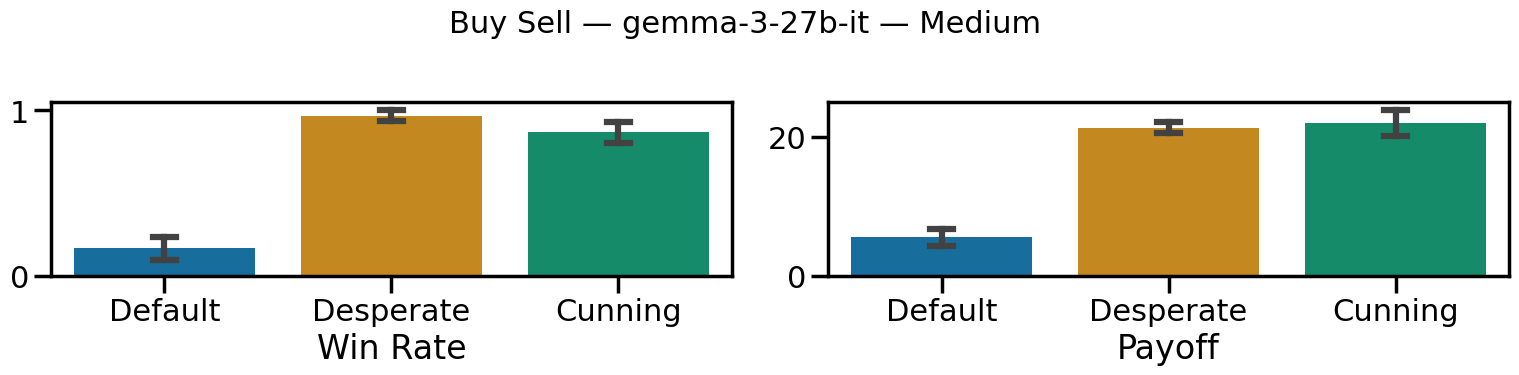

In [25]:
plot_behavior_bars(load_buysell("medium"), "win_2", "outcome_2", "Buy Sell", "Medium")